In [ ]:
from __future__ import annotations

# Стандартная библиотека: пути к файлам, регулярные выражения и служебные операции.
import importlib
import importlib.util
from pathlib import Path
import re
import subprocess
import sys
from typing import Any, Callable, Mapping, Optional, Sequence

# Численные расчеты и таблицы: массивы, табличные структуры и типы массивов.
import numpy as np
from numpy.typing import NDArray
import pandas as pd

# Сигнальная обработка и статистика: чтение MAT-файлов, фильтрация и расчет признаков.
import scipy.io as sio
from scipy import signal, stats
from scipy.stats import kurtosis, skew

# Визуализация: графики сигналов, спектров и корреляций.
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import seaborn as sns

# Модели и оценка: разбиения, метрики и baseline-алгоритмы классификации.
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# Интеграция с Google Colab: подключение Google Drive в исходной среде разработки.
from google.colab import drive

# Алиас вещественных numpy-массивов.
FloatArray = NDArray[np.floating]


In [ ]:
# Установка xgboost и catboost в самом начале ноутбука (если пакетов нет).
for pkg in ["xgboost", "catboost"]:
    if importlib.util.find_spec(pkg) is None:
        print(f"Устанавливается пакет: {pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
# print("xgboost/catboost готовы к использованию.")


## Цель проекта
Проект решает задачу классификации дефектов подшипников по вибросигналам. В качстве данных для обучения были использованы данные записанные на реальном производстве (SCA Bearing Dataset).
На текущем этапе в сравнение включены модели `RandomForest`, `GradientBoosting`, `XGBoost` и `CatBoost`,
чтобы получить воспроизводимую оценку качества на текущем наборе инженерных признаков.


## Особенности датасета
SCA Bearing Dataset содержит промышленные временные ряды с разной частотой дискретизации, неоднородными
режимами работы и дисбалансом классов. Важные метки: `-1` (остановлен / нет скорости вала) и классы `0..3`
для состояний (дефект отсуствует, дефект внутреннего кольца, дефект шарика, дефект внешнего кольца). Кейс `11` не обрабатывается в рамках текущей работы из-за того, что связан не с дефектами подшипинка, в несоосностью вала (расцентровка).


### Загрузка и подготовка файлов MATLAB для дальнейшей работы

#### Загрузка данных с Drive

In [ ]:
if drive is None:
    raise ImportError("Ноутбук рассчитан на запуск в Google Colab, где доступен модуль google.colab.")

drive.mount("/content/drive")

mat_root = Path("/content/drive/MyDrive/SCA_bearing_dataset_2")
assert mat_root.exists(), f"Папка не найдена: {mat_root}"

# Рекурсивно ищем все MAT-файлы независимо от регистра расширения.
mat_files = sorted([p for p in mat_root.rglob("*") if p.is_file() and p.suffix.lower() == ".mat"])
print("MAT files found:", len(mat_files))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MAT files found: 22


#### Вспомогательные функции для получения данных из таблицы, полученной из .mat файлов

In [ ]:
def _scalar(x: Any) -> Any:
    """Преобразует типичные MATLAB-скаляры из numpy-контейнеров в Python-значения."""
    if isinstance(x, np.ndarray):
        if x.shape == (1, 1):
            return x.item()
        if x.shape == (1,):
            return x[0]
    return x


def _get_field(obj: Any, name: str, default: Any = None) -> Any:
    """Достает поле из MATLAB-структуры, dict или numpy-записи."""
    # Поддержка numpy structured array.
    if isinstance(obj, np.ndarray) and obj.dtype.names is not None:
        return obj[name]
    if hasattr(obj, "get"):
        return obj.get(name, default)
    # Поддержка scipy mat_struct с доступом к атрибутам.
    if hasattr(obj, name):
        return getattr(obj, name, default)
    # Последняя попытка для dict-like объектов.
    try:
        return obj[name]
    except Exception as exc:
        raise KeyError(f"Field '{name}' not found") from exc


def _safe_float(x: Any, default: float = np.nan) -> float:
    """Безопасно приводит значение к float или возвращает default."""
    try:
        return float(np.asarray(x).squeeze())
    except Exception:
        return default


def _parse_time_vector(t_raw: Any) -> pd.DatetimeIndex:
    """Переводит сырой вектор времени в pandas.DatetimeIndex."""
    s = pd.Series(np.asarray(t_raw).ravel(), dtype="string").str.strip()
    return pd.to_datetime(s, format="ISO8601", errors="coerce")


def load_mat_clean(path: Path) -> dict[str, Any]:
    """Загружает MAT-файл и убирает служебные MATLAB-ключи."""
    # Используем базовый режим loadmat, чтобы избежать разногласий между версиями scipy.
    d = sio.loadmat(str(path), struct_as_record=False, squeeze_me=False)
    return {k: v for k, v in d.items() if not k.startswith("__")}


def parse_case_split(path: Path) -> tuple[str, str]:
    """Извлекает case_id и split из пути к MAT-файлу."""
    case_id = path.parent.name
    split = path.stem.lower()
    return case_id, split


def infer_placements(d: dict[str, Any]) -> list[str]:
    """Автоматически находит площадки измерения по наличию rawData."""
    placements: list[str] = []
    for k, v in d.items():
        if k.startswith("__"):
            continue
        if isinstance(v, np.ndarray) and v.dtype == object and v.size == 1:
            rec = v.ravel()[0]
            if hasattr(rec, "_fieldnames") and ("rawData" in rec._fieldnames):
                placements.append(k)
    return placements


def to_rows_and_signals(
    d: dict[str, Any],
    source_file: str,
    case_id: str,
    split: str,
    placements: Optional[Sequence[str]] = None,
    drop_label_minus1: bool = True,
    drop_missing_rpm: bool = True,
) -> tuple[list[dict[str, Any]], list[np.ndarray]]:
    """Преобразует MAT-файл в таблицу метаданных и список сигналов."""
    if placements is None:
        placements = infer_placements(d)

    meta_top = {
        "source_file": source_file,
        "case_id": case_id,
        "split": split,
        "id": _scalar(d.get("id")),
        "bearing": d.get("assetName"),
        "assetDescription": _scalar(d.get("assetDescription")),
        "faultOrigin": _scalar(d.get("faultOrigin")),
        "faultType": _scalar(d.get("faultType")),
        "fromDate": pd.to_datetime(_scalar(d.get("fromDate")), errors="coerce"),
        "toDate": pd.to_datetime(_scalar(d.get("toDate")), errors="coerce"),
        "fixedSpeed": _scalar(d.get("fixedSpeed")),
    }

    rows: list[dict[str, Any]] = []
    sigs: list[np.ndarray] = []

    for placement in placements:
        if placement not in d:
            continue

        # В scipy площадка часто хранится как ndarray(1, 1) с объектом внутри.
        rec_container = d[placement]
        rec = rec_container.ravel()[0]

        assetName = _scalar(_get_field(rec, "assetName"))
        unit = _scalar(_get_field(rec, "unit"))

        ff = _get_field(rec, "faultFrequencies")
        ff0 = ff.ravel()[0] if isinstance(ff, np.ndarray) else ff
        ff_dict = {
            "FTFMultiple": _safe_float(_get_field(ff0, "FTFMultiple")),
            "BPFMultiple": _safe_float(_get_field(ff0, "BPFMultiple")),
            "BPFOMultiple": _safe_float(_get_field(ff0, "BPFOMultiple")),
            "BPFIMultiple": _safe_float(_get_field(ff0, "BPFIMultiple")),
        }

        t = _parse_time_vector(_get_field(rec, "time"))
        rpm = np.asarray(_get_field(rec, "RPM")).ravel().astype(float)
        sr = np.asarray(_get_field(rec, "samplingRate")).ravel().astype(float)
        lab = np.asarray(_get_field(rec, "label")).ravel().astype(int)

        # Для MATLAB cell array получаем object-массив, для матрицы — обычный ndarray.
        raw = np.asarray(_get_field(rec, "rawData")).squeeze()
        raw_n = raw.size if raw.dtype == object else raw.shape[0]

        n = len(t)
        if not (len(rpm) == len(sr) == len(lab) == raw_n == n):
            raise ValueError(
                f"Inconsistent lengths for {placement} in {source_file}: "
                f"time={n}, rpm={len(rpm)}, sr={len(sr)}, lab={len(lab)}, raw_n={raw_n}, raw_shape={getattr(raw, 'shape', None)}"
            )

        for i in range(n):
            if pd.isna(t[i]):
                continue
            if drop_label_minus1 and lab[i] == -1:
                continue
            if drop_missing_rpm and (not np.isfinite(rpm[i]) or rpm[i] <= 0):
                continue

            sig_raw = raw.ravel()[i] if raw.dtype == object else raw[i]
            sig = np.asarray(sig_raw, dtype=np.float32).ravel()

            idx = len(sigs)
            sigs.append(sig)
            rows.append({
                **meta_top,
                "placement": placement,
                "assetName": assetName,
                "unit": unit,
                **ff_dict,
                "time": t[i],
                "RPM": float(rpm[i]),
                "samplingRate": float(sr[i]),
                "label": int(lab[i]),
                "signal_idx": idx,
            })

    return rows, sigs


#### Загрузка и парсинг .mat файлов

In [ ]:
all_rows = []
all_sigs = []
offset = 0  # Глобальное смещение индекса сигнала между файлами.

bad = []

for p in mat_files:
    try:
        d = load_mat_clean(p)
        case_id, split = parse_case_split(p)
        rows, sigs = to_rows_and_signals(
            d,
            source_file=str(p),
            case_id=case_id,
            split=split,
            placements=None,            # Площадки измерения определяем автоматически.
            drop_label_minus1=True,
            drop_missing_rpm=True,
        )

        # Сдвигаем локальные signal_idx, чтобы собрать единый список сигналов.
        for r in rows:
            r["signal_idx"] += offset

        offset += len(sigs)
        all_rows.extend(rows)
        all_sigs.extend(sigs)

    except Exception as e:
        bad.append((str(p), repr(e)))

print("Parsed rows:", len(all_rows))
print("Signals:", len(all_sigs))
print("Bad files:", len(bad))
if bad:
    print("Bad examples:", bad[:3])

df_meta = pd.DataFrame(all_rows)

# Стабильная числовая сортировка case_id удобна для диагностики и отладки.
df_meta["case_id_int"] = df_meta["case_id"].astype(int)

# Нормализуем faultOrigin заранее, чтобы потом его было проще фильтровать.
df_meta["faultOrigin"] = df_meta["faultOrigin"].astype("string").str.strip()

df_meta = df_meta.sort_values(["case_id_int", "split", "placement", "time"]).reset_index(drop=True)

# Сигналы храним отдельным списком, так как их длина может отличаться между кейсами.
X_signals = all_sigs
y_labels = df_meta["label"].to_numpy(np.int64)

df_meta["sig_len"] = df_meta["signal_idx"].map(lambda i: len(X_signals[int(i)]))

sig_lens = df_meta["sig_len"]
print("Signal length stats:", int(sig_lens.min()), int(sig_lens.max()))
print("Most common lengths:", sig_lens.value_counts().head(5).to_dict())

print("df_meta:", df_meta.shape)
print("labels:", np.unique(y_labels, return_counts=True))


Parsed rows: 6446
Signals: 6446
Bad files: 0
Signal length stats: 8192 16384
Most common lengths: {16384: 5906, 8192: 540}
df_meta: (6446, 25)
labels: (array([0, 1, 2, 3]), array([5598,  372,   23,  453]))


#### Вывод полученного DF из .mat файлов

In [ ]:
df_meta.head()

,source_file,case_id,split,id,bearing,assetDescription,faultOrigin,faultType,fromDate,toDate,...,BPFMultiple,BPFOMultiple,BPFIMultiple,time,RPM,samplingRate,label,signal_idx,case_id_int,sig_len
0,/content/drive/MyDrive/SCA_bearing_dataset_2/1...,1,test,1,None,Roller,DS,1,2022-01-01 19:00:06,2022-05-10 19:00:06,...,0.213265,0.52441,0.748816,2022-01-10 23:01:22.290,1228.76453,640.0,1,0,1,16384
1,/content/drive/MyDrive/SCA_bearing_dataset_2/1...,1,test,1,None,Roller,DS,1,2022-01-01 19:00:06,2022-05-10 19:00:06,...,0.213265,0.52441,0.748816,2022-01-11 22:00:03.820,1228.97961,640.0,1,1,1,16384
2,/content/drive/MyDrive/SCA_bearing_dataset_2/1...,1,test,1,None,Roller,DS,1,2022-01-01 19:00:06,2022-05-10 19:00:06,...,0.213265,0.52441,0.748816,2022-01-12 21:01:23.960,1228.57227,640.0,1,2,1,16384
3,/content/drive/MyDrive/SCA_bearing_dataset_2/1...,1,test,1,None,Roller,DS,1,2022-01-01 19:00:06,2022-05-10 19:00:06,...,0.213265,0.52441,0.748816,2022-01-13 20:00:07.580,1195.84790,640.0,1,3,1,16384
4,/content/drive/MyDrive/SCA_bearing_dataset_2/1...,1,test,1,None,Roller,DS,1,2022-01-01 19:00:06,2022-05-10 19:00:06,...,0.213265,0.52441,0.748816,2022-01-14 19:00:54.270,958.09710,640.0,1,4,1,16384


#### Очистка базового датасета и группировка по fs

In [ ]:
df_meta_clean = df_meta.copy()

# базовая очистка
df_meta_clean = df_meta_clean[df_meta_clean["time"].notna()]
df_meta_clean = df_meta_clean[np.isfinite(df_meta_clean["samplingRate"])]
df_meta_clean = df_meta_clean[df_meta_clean["samplingRate"] > 0]
df_meta_clean = df_meta_clean[df_meta_clean["label"].isin([0,1,2,3])]
df_meta_clean = df_meta_clean[df_meta_clean["sig_len"] >= 1024]  # на всякий случай

# группировка по fs
FS_SPLIT = 4000.0
df_meta_clean["fs_group"] = np.where(df_meta_clean["samplingRate"] < FS_SPLIT, "low_fs", "high_fs")

# Доп. фильтр для high_fs: проверяем, что частоты дефектов влезают в Nyquist
MAX_H = 2
fr = df_meta_clean["RPM"] / 60.0
nyq = df_meta_clean["samplingRate"] / 2.0

max_mult = df_meta_clean[["FTFMultiple","BPFMultiple","BPFOMultiple","BPFIMultiple"]].max(axis=1)
fmax = max_mult * fr * MAX_H

df_meta_clean["ok_nyq_h2"] = fmax < (0.95 * nyq)

df_meta_low  = df_meta_clean[df_meta_clean["fs_group"] == "low_fs"].copy()
df_meta_high = df_meta_clean[(df_meta_clean["fs_group"] == "high_fs") & (df_meta_clean["ok_nyq_h2"])].copy()

print("meta_clean:", df_meta_clean.shape)
print("low_fs:", df_meta_low.shape, "high_fs:", df_meta_high.shape)
print(df_meta_clean["fs_group"].value_counts())

# временное решение??
df_meta = df_meta_high

meta_clean: (6446, 27)
low_fs: (1027, 27) high_fs: (5419, 27)
fs_group
high_fs    5419
low_fs     1027
Name: count, dtype: int64


In [ ]:
# Добавляем row_id, чтобы использовать для объединеия отдельных dataframes (понадобится на этапе подготовки данных)
df_meta = df_meta.reset_index(drop=True).reset_index().rename(columns={"index": "row_id"})

In [ ]:
df_meta.head()

,row_id,source_file,case_id,split,id,bearing,assetDescription,faultOrigin,faultType,fromDate,...,BPFIMultiple,time,RPM,samplingRate,label,signal_idx,case_id_int,sig_len,fs_group,ok_nyq_h2
0,0,/content/drive/MyDrive/SCA_bearing_dataset_2/2...,2,test,2,None,Engine,DS,3,2021-12-01,...,4.95,2021-12-01 17:00:05.920,1162.0,5120.0,3,1034,2,16384,high_fs,True
1,1,/content/drive/MyDrive/SCA_bearing_dataset_2/2...,2,test,2,None,Engine,DS,3,2021-12-01,...,4.95,2021-12-02 16:00:29.050,1162.0,5120.0,3,1035,2,16384,high_fs,True
2,2,/content/drive/MyDrive/SCA_bearing_dataset_2/2...,2,test,2,None,Engine,DS,3,2021-12-01,...,4.95,2021-12-03 15:00:04.260,1162.0,5120.0,3,1036,2,16384,high_fs,True
3,3,/content/drive/MyDrive/SCA_bearing_dataset_2/2...,2,test,2,None,Engine,DS,3,2021-12-01,...,4.95,2021-12-04 14:00:44.990,1162.0,5120.0,3,1037,2,16384,high_fs,True
4,4,/content/drive/MyDrive/SCA_bearing_dataset_2/2...,2,test,2,None,Engine,DS,3,2021-12-01,...,4.95,2021-12-05 13:00:10.640,1162.0,5120.0,3,1038,2,16384,high_fs,True


### Вспомогательные функции

#### Преобразование BPFO, BPFI, BSF, FTF из датасета (multiples) к набору частот (Гц)

In [ ]:
def characteristic_freqs_hz_from_multiples(row: Any) -> dict[str, float]:
    """Преобразует кратности дефектных частот из датасета в частоты в Гц."""
    rpm = float(_get_field(row, "RPM"))
    fr = rpm / 60.0

    out: dict[str, float] = {}
    ftf_m = _get_field(row, "FTFMultiple")
    bsf_m = _get_field(row, "BPFMultiple")
    bpfi_m = _get_field(row, "BPFIMultiple")
    bpfo_m = _get_field(row, "BPFOMultiple")

    if ftf_m is not None and np.isfinite(ftf_m):
        out["FTF"] = float(ftf_m) * fr
    if bsf_m is not None and np.isfinite(bsf_m):
        out["BSF"] = float(bsf_m) * fr
    if bpfi_m is not None and np.isfinite(bpfi_m):
        out["BPFI"] = float(bpfi_m) * fr
    if bpfo_m is not None and np.isfinite(bpfo_m):
        out["BPFO"] = float(bpfo_m) * fr
    out["fr"] = fr

    return out


#### СКЗ, FFT, Огибающая

In [ ]:
def rms(x: np.ndarray) -> float:
    """Вычисляет среднеквадратичное значение сигнала во временной области."""
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x * x)))


def rfft_mag(x: np.ndarray, fs: float, window: Optional[str] = "hann") -> tuple[FloatArray, FloatArray]:
    """Строит односторонний нормализованный амплитудный спектр через rFFT."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)  # Убираем DC-составляющую перед FFT.

    n = len(x)
    w = np.ones(n) if window is None else signal.get_window(window, n, fftbins=True)
    X = np.fft.rfft(x * w)
    f = np.fft.rfftfreq(n, d=1.0 / fs)

    # Нормировка удобна для сравнения спектров и расчета фичей.
    mag = np.abs(X) / (np.sum(w) / 2.0)

    if n % 2 == 0:
        mag[1:-1] *= 2.0
    else:
        mag[1:] *= 2.0

    return f, mag


def rfft_amp(x: np.ndarray, fs: float, window: Optional[str] = "hann") -> tuple[FloatArray, FloatArray]:
    """Возвращает односторонний спектр амплитуд с учетом coherent gain окна."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)

    w = np.ones(n) if window is None else signal.get_window(window, n, fftbins=True)
    cg = np.mean(w)
    X = np.fft.rfft(x * w)
    amp = np.abs(X) / (n * cg)

    if n % 2 == 0:
        amp[1:-1] *= 2.0
    else:
        amp[1:] *= 2.0

    f = np.fft.rfftfreq(n, d=1.0 / fs)
    return f, amp


def rms_from_rfft(x: np.ndarray) -> float:
    """Вычисляет RMS через теорему Парсеваля для проверки расчетов."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)

    X = np.fft.rfft(x)
    p = np.abs(X) ** 2

    # Восстанавливаем энергию полного FFT из одностороннего спектра.
    if n % 2 == 0:
        sum_X_full = p[0] + p[-1] + 2.0 * np.sum(p[1:-1])
    else:
        sum_X_full = p[0] + 2.0 * np.sum(p[1:])

    rms2 = (1.0 / (n * n)) * sum_X_full
    return float(np.sqrt(rms2))


def butter_bandpass(
    x: np.ndarray,
    fs: float,
    low_hz: float,
    high_hz: float,
    order: int = 4,
) -> FloatArray:
    """Применяет нулефазовый Butterworth-фильтр в заданной полосе частот."""
    nyq = 0.5 * fs
    low = max(low_hz / nyq, 1e-6)
    high = min(high_hz / nyq, 0.999999)

    if high <= low:
        # При некорректной полосе возвращаем исходный сигнал, чтобы не падать на редких кейсах.
        return np.asarray(x, dtype=float)

    b, a = signal.butter(order, [low, high], btype="bandpass")
    return signal.filtfilt(b, a, np.asarray(x, dtype=float))


def envelope_hilbert(
    x: np.ndarray,
    fs: float,
    band: Optional[tuple[float, float]] = None,
) -> FloatArray:
    """Строит огибающую через аналитический сигнал Гильберта."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    if band is not None:
        x = butter_bandpass(x, fs, band[0], band[1], order=4)

    analytic = signal.hilbert(x)
    return np.abs(analytic)


#### Отрисовка линий

In [ ]:
def add_fault_lines_fs(
    ax: Axes,
    freqs_hz: Mapping[str, float],
    max_harmonics: int = 5,
) -> None:
    """Добавляет на график линии частот дефектов и их гармоник."""
    color_map = {
        "BPFO": "tab:orange",
        "BPFI": "tab:blue",
        "FTF": "tab:green",
        "BSF": "tab:red",
        "fr": "tab:purple",
    }

    for name, f0 in freqs_hz.items():
        if not np.isfinite(f0) or f0 <= 0:
            continue
        for h in range(1, max_harmonics + 1):
            fh = h * f0
            ax.axvline(
                fh,
                color=color_map.get(name, "k"),
                linestyle="--" if h == 1 else ":",
                linewidth=1.6 if h == 1 else 1.2,
                alpha=0.85 if h == 1 else 0.65,
                label=(name if h == 1 else f"{h}h{name}"),
            )


#### Энергия около оборотных гармоник

In [ ]:
def band_energy_around(
    f: FloatArray,
    mag: FloatArray,
    center_hz: Optional[float],
    half_width_hz: float,
) -> float:
    """Суммирует энергию спектра вокруг заданной частоты."""
    if center_hz is None or not np.isfinite(center_hz) or center_hz <= 0.0:
        return 0.0
    if not np.isfinite(half_width_hz) or half_width_hz <= 0.0:
        return 0.0
    if f.shape != mag.shape:
        raise ValueError(f"`f` and `mag` must have the same shape, got {f.shape} vs {mag.shape}")

    lo = center_hz - half_width_hz
    hi = center_hz + half_width_hz
    mask = (f >= lo) & (f <= hi)
    if not np.any(mask):
        return 0.0

    return float(np.sum(mag[mask] ** 2))


#### Пики около частот дефектов на спектре огибающей

In [ ]:
def peak_near(
    f: FloatArray,
    mag: FloatArray,
    center_hz: Optional[float],
    half_width_hz: float,
) -> float:
    """Ищет максимум амплитуды в окне вокруг заданной частоты."""
    if center_hz is None or not np.isfinite(center_hz) or center_hz <= 0.0:
        return 0.0
    mask = (f >= (center_hz - half_width_hz)) & (f <= (center_hz + half_width_hz))
    if not np.any(mask):
        return 0.0
    return float(np.max(mag[mask]))


def auto_half_width_hz(fs: float, n: int, min_width: float = 0.5, bins: int = 3) -> float:
    """Выбирает ширину окна как несколько FFT-бинов, но не уже min_width."""
    df = fs / n
    return float(max(min_width, bins * df))


### Анализ расчетов, вывод графиков сигнала, спектров и линий частот дефектов на них

#### Расчет FFT сигнала и огибающей + считаем частоты дефектов

In [ ]:
i = 0  # Индекс строки df_meta для ручной проверки.
row = df_meta.iloc[i]
x = X_signals[int(row.signal_idx)]
fs = float(row.samplingRate)
rpm = _get_field(row, "RPM")
lbl = _get_field(row, "label")

match lbl:
    case 0:
        print("normal")
    case 1:
        print("inner fault")
    case 2:
        print("ball fault")
    case 3:
        print("outer fault")
    case _:
        print("unknown label")

print(f"fr(shaft frequency): {rpm / 60}")

# 1) Считаем FFT сырого сигнала.
f, mag = rfft_mag(x, fs)
_, amp = rfft_amp(x, fs)

# 2) Строим огибающую в эвристической полосе резонанса.
low = max(10.0, 0.10 * fs)
high = min(0.45 * fs, 0.49 * fs)
env = envelope_hilbert(x, fs, band=(low, high))

# 3) Для спектра огибающей убираем ее среднее значение.
env_ac = env - np.mean(env)
f_env, mag_env = rfft_mag(env_ac, fs)
_, amp_env = rfft_amp(env_ac, fs)

# Преобразуем multiples из метаданных в реальные частоты дефектов.
freqs = characteristic_freqs_hz_from_multiples(row)

# Сравниваем RMS из временной области и из FFT как sanity-check.
rms_raw = rms(x)
rms_raw_fft = rms_from_rfft(x)

rms_env = rms(env)
rms_env_ac = rms(env_ac)
rms_env_fft = rms_from_rfft(env_ac)

(rms_raw, rms_raw_fft, rms_env, rms_env_ac, rms_env_fft, freqs)


outer fault
fr(shaft frequency): 19.366666666666667


(1.0323443642589247,
 1.0323443611894125,
 1.277283641483883,
 0.5682044337970228,
 0.5682044337970228,
 {'FTF': 7.359333333333334,
  'BSF': 38.346000000000004,
  'BPFI': 95.86500000000001,
  'BPFO': 59.06833333333333,
  'fr': 19.366666666666667})

#### Графики без линий

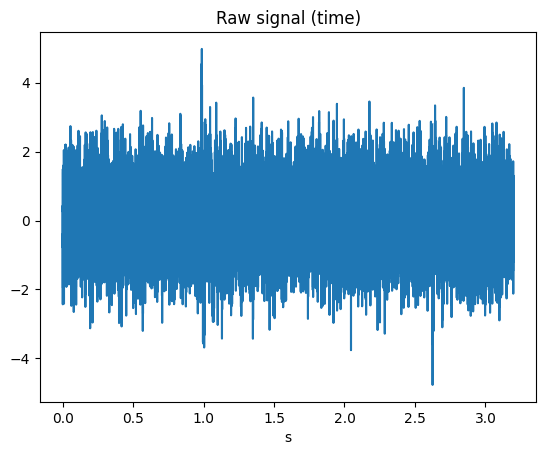

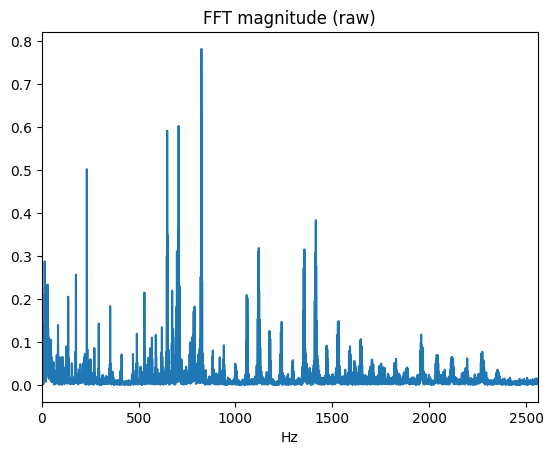

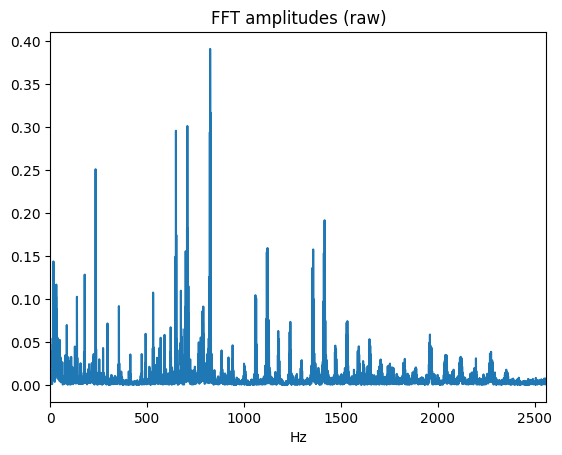

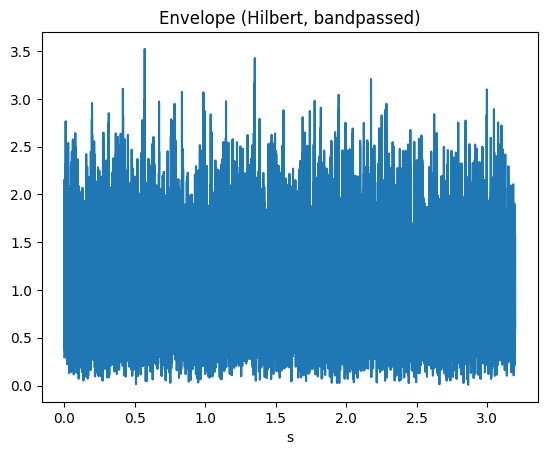

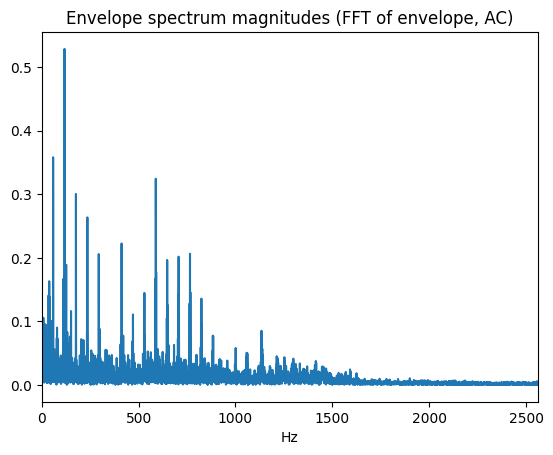

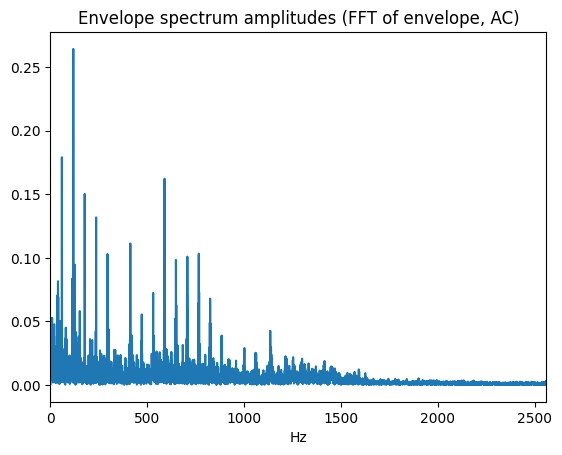

In [ ]:
t = np.arange(len(x)) / fs

plt.figure()
plt.plot(t, x)
plt.title("Raw signal (time)")
plt.xlabel("s")

plt.figure()
plt.plot(f, mag)
plt.title("FFT magnitude (raw)")
plt.xlabel("Hz")
plt.xlim(0, fs/2)

plt.figure()
plt.plot(f, amp)
plt.title("FFT amplitudes (raw)")
plt.xlabel("Hz")
plt.xlim(0, fs/2)

plt.figure()
plt.plot(t, env)
plt.title("Envelope (Hilbert, bandpassed)")
plt.xlabel("s")

plt.figure()
plt.plot(f_env, mag_env)
plt.title("Envelope spectrum magnitudes (FFT of envelope, AC)")
plt.xlabel("Hz")
plt.xlim(0, fs/2)

plt.figure()
plt.plot(f_env, amp_env)
plt.title("Envelope spectrum amplitudes (FFT of envelope, AC)")
plt.xlabel("Hz")
plt.xlim(0, fs/2)

plt.show()

#### Графики с линиями частот дефектов

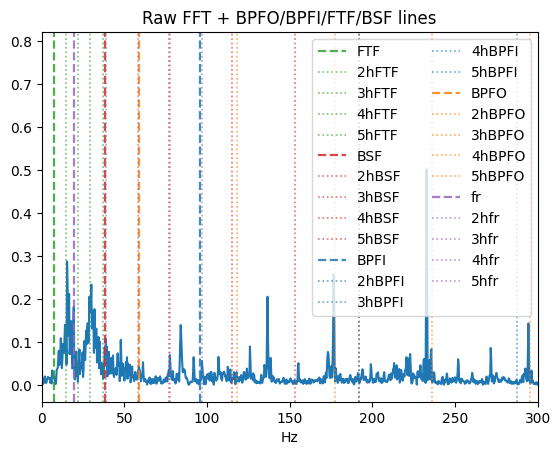

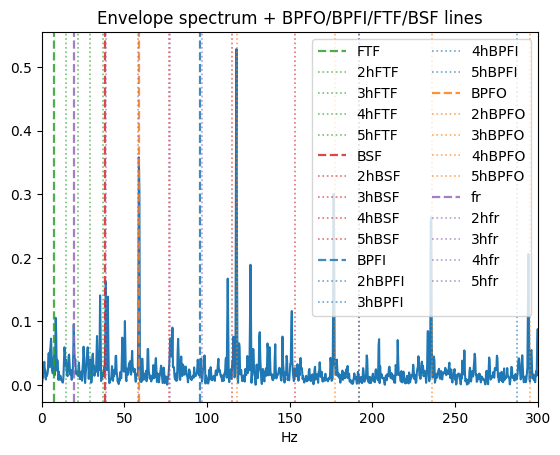

In [ ]:
# График FFT сырого сигнала с нанесенными частотами дефектов.
fig, ax = plt.subplots()
ax.plot(f, mag)
add_fault_lines_fs(ax, freqs, max_harmonics=5)
ax.set_title("Raw FFT + BPFO/BPFI/FTF/BSF lines")
ax.set_xlabel("Hz")
ax.set_xlim(0, 300)
ax.legend(loc="upper right", ncols=2)
plt.show()

# График спектра огибающей: здесь чаще всего интересен низкочастотный диапазон.
fig, ax = plt.subplots()
ax.plot(f_env, mag_env)
add_fault_lines_fs(ax, freqs, max_harmonics=5)
ax.set_title("Envelope spectrum + BPFO/BPFI/FTF/BSF lines")
ax.set_xlabel("Hz")
ax.set_xlim(0, 300)
ax.legend(loc="upper right", ncols=2)
plt.show()


### Подготовка данных для обучения

#### СКЗ df_1

In [ ]:
rms_raw_list = []
rms_env_list = []
rms_env_ac_list = []

# Списки для FFT-RMS оставляем как проверку корректности, а не как основные фичи.
rms_raw_fft_list = []
rms_env_ac_fft_list = []

for row in df_meta.itertuples(index=False):
    x = X_signals[int(row.signal_idx)]
    fs = float(row.samplingRate)

    # Для всех записей берем одинаковую эвристику полосы для огибающей.
    low = max(10.0, 0.10 * fs)
    high = min(0.45 * fs, 0.49 * fs)

    env = envelope_hilbert(x, fs, band=(low, high))
    env_ac = env - np.mean(env)

    rms_raw_list.append(rms(x))
    rms_env_list.append(rms(env))
    rms_env_ac_list.append(rms(env_ac))

    rms_raw_fft_list.append(rms_from_rfft(x))
    rms_env_ac_fft_list.append(rms_from_rfft(env_ac))

df_feat = pd.DataFrame()
df_feat["rms_raw"] = rms_raw_list
df_feat["rms_env_ac"] = rms_env_ac_list

# Дополнительные колонки оставляем закомментированными: они полезны для ручной диагностики.
# df_feat["rms_env"] = rms_env_list
# df_feat["rms_raw_fft_check"] = rms_raw_fft_list
# df_feat["rms_env_ac_fft_check"] = rms_env_ac_fft_list

df_feat[["rms_raw", "rms_env_ac"]].describe()


,rms_raw,rms_env_ac
count,5419.000000,5419.000000
mean,2.553989,1.200503
std,2.583406,1.548357
min,0.004166,0.001672
25%,0.967327,0.400865
50%,1.842366,0.760635
75%,2.882908,1.523491
max,29.520630,20.704110


##### Корреляции

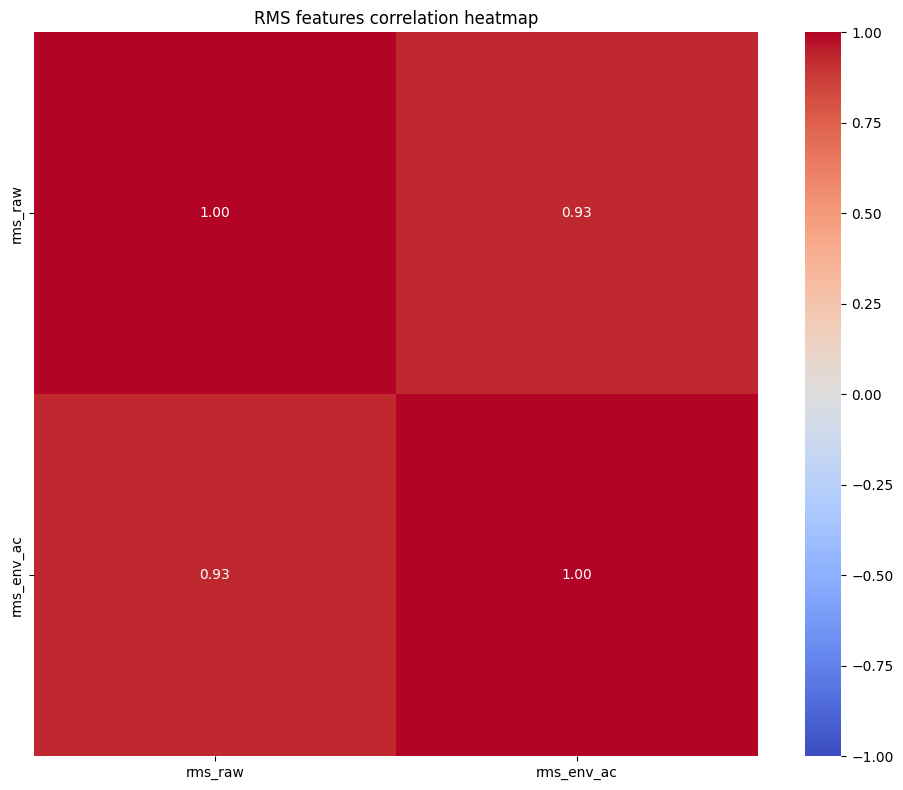

In [ ]:
corr = df_feat.select_dtypes(include="number").corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("RMS features correlation heatmap")
plt.tight_layout()
plt.show()

#### Временные призаки

In [ ]:
def basic_time_features(x: np.ndarray, prefix: str = "raw", removeDC=True) -> dict[str, float]:
    """Считает базовые временные признаки для заданного сигнала."""
    x = np.asarray(x, dtype=float)
    if removeDC:
      x = x - np.mean(x)

    rms_v = np.sqrt(np.mean(x * x))
    peak = np.max(np.abs(x))
    mean_abs = np.mean(np.abs(x))
    std = np.std(x)

    feats = {
        f"std_{prefix}": float(std),
        f"mean_abs_{prefix}": float(mean_abs),
        f"peak_{prefix}": float(peak),
        f"ptp_{prefix}": float(np.ptp(x)),
        f"skew_{prefix}": float(skew(x, bias=False)),
        f"kurtosis_{prefix}": float(kurtosis(x, fisher=True, bias=False)),  # Эксцесс хорошо ловит импульсные изменения.
        f"crest_factor_{prefix}": float(peak / (rms_v + 1e-12)),
        f"impulse_factor_{prefix}": float(peak / (mean_abs + 1e-12)),
    }
    return feats


#### Признаки по огибающей

In [ ]:
def envelope_features(
    x: np.ndarray,
    fs: float,
    band: Optional[tuple[float, float]] = None,
) -> dict[str, float]:
    """Вычисляет временные признаки огибающей и ее AC-составляющей."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    if band is not None:
        low_hz, high_hz = band
        nyq = fs / 2.0
        low = max(low_hz / nyq, 1e-6)
        high = min(high_hz / nyq, 0.999999)
        if high > low:
            b, a = signal.butter(4, [low, high], btype="bandpass")
            x = signal.filtfilt(b, a, x)

    env = np.abs(signal.hilbert(x))
    env_ac = env - np.mean(env)  # В AC-варианте убираем постоянную составляющую огибающей.

    feats: dict[str, float] = {}
    feats.update(basic_time_features(env, prefix="env", removeDC=False))
    feats.update(basic_time_features(env_ac, prefix="env_ac", removeDC=False))
    return feats


#### Добавляем временные признаки (сырой сигнал + огибающая) df_2

In [ ]:
rows = []
for row in df_meta.itertuples(index=False):
    x = X_signals[int(row.signal_idx)]
    fs = float(row.samplingRate)

    # Используем ту же эвристику полосы, что и в блоке RMS-признаков.
    low = max(10.0, 0.10 * fs)
    high = min(0.45 * fs, 0.49 * fs)

    feats = {}
    feats.update(basic_time_features(x, prefix="raw"))
    feats.update(envelope_features(x, fs, band=(low, high)))

    rows.append(feats)

df_feat2 = pd.DataFrame(rows)
df_feat2.tail()


,std_raw,mean_abs_raw,peak_raw,ptp_raw,skew_raw,kurtosis_raw,crest_factor_raw,impulse_factor_raw,std_env,mean_abs_env,...,crest_factor_env,impulse_factor_env,std_env_ac,mean_abs_env_ac,peak_env_ac,ptp_env_ac,skew_env_ac,kurtosis_env_ac,crest_factor_env_ac,impulse_factor_env_ac
5414,1.804004,1.445620,7.298140,13.873791,-0.030012,-0.123325,4.045522,5.048449,1.021666,2.001335,...,2.810606,3.155652,1.021666,0.831782,4.314180,6.283426,0.494155,-0.141630,4.222690,5.186673
5415,1.901274,1.528993,7.596988,14.068789,0.020477,-0.144795,3.995736,4.968622,1.072642,2.165661,...,2.834640,3.163283,1.072642,0.869122,4.684937,6.823249,0.454326,-0.060843,4.367660,5.390426
5416,1.823437,1.468324,6.749409,13.283479,0.002405,-0.200694,3.701476,4.596676,1.024539,2.055181,...,2.791417,3.119048,1.024539,0.829183,4.355026,6.398474,0.507949,-0.079210,4.250720,5.252189
5417,1.851291,1.484238,6.552453,12.852712,-0.005897,-0.108142,3.539396,4.414693,1.049261,2.092657,...,2.775546,3.104896,1.049261,0.848975,4.404826,6.470611,0.501688,-0.085293,4.198028,5.188404
5418,1.805761,1.447604,7.125296,13.319524,-0.026725,-0.118916,3.945870,4.922132,1.007039,1.988200,...,2.886208,3.235322,1.007039,0.815784,4.444268,6.426219,0.520972,-0.053307,4.413204,5.447850


##### Удаляем избыточные признаки

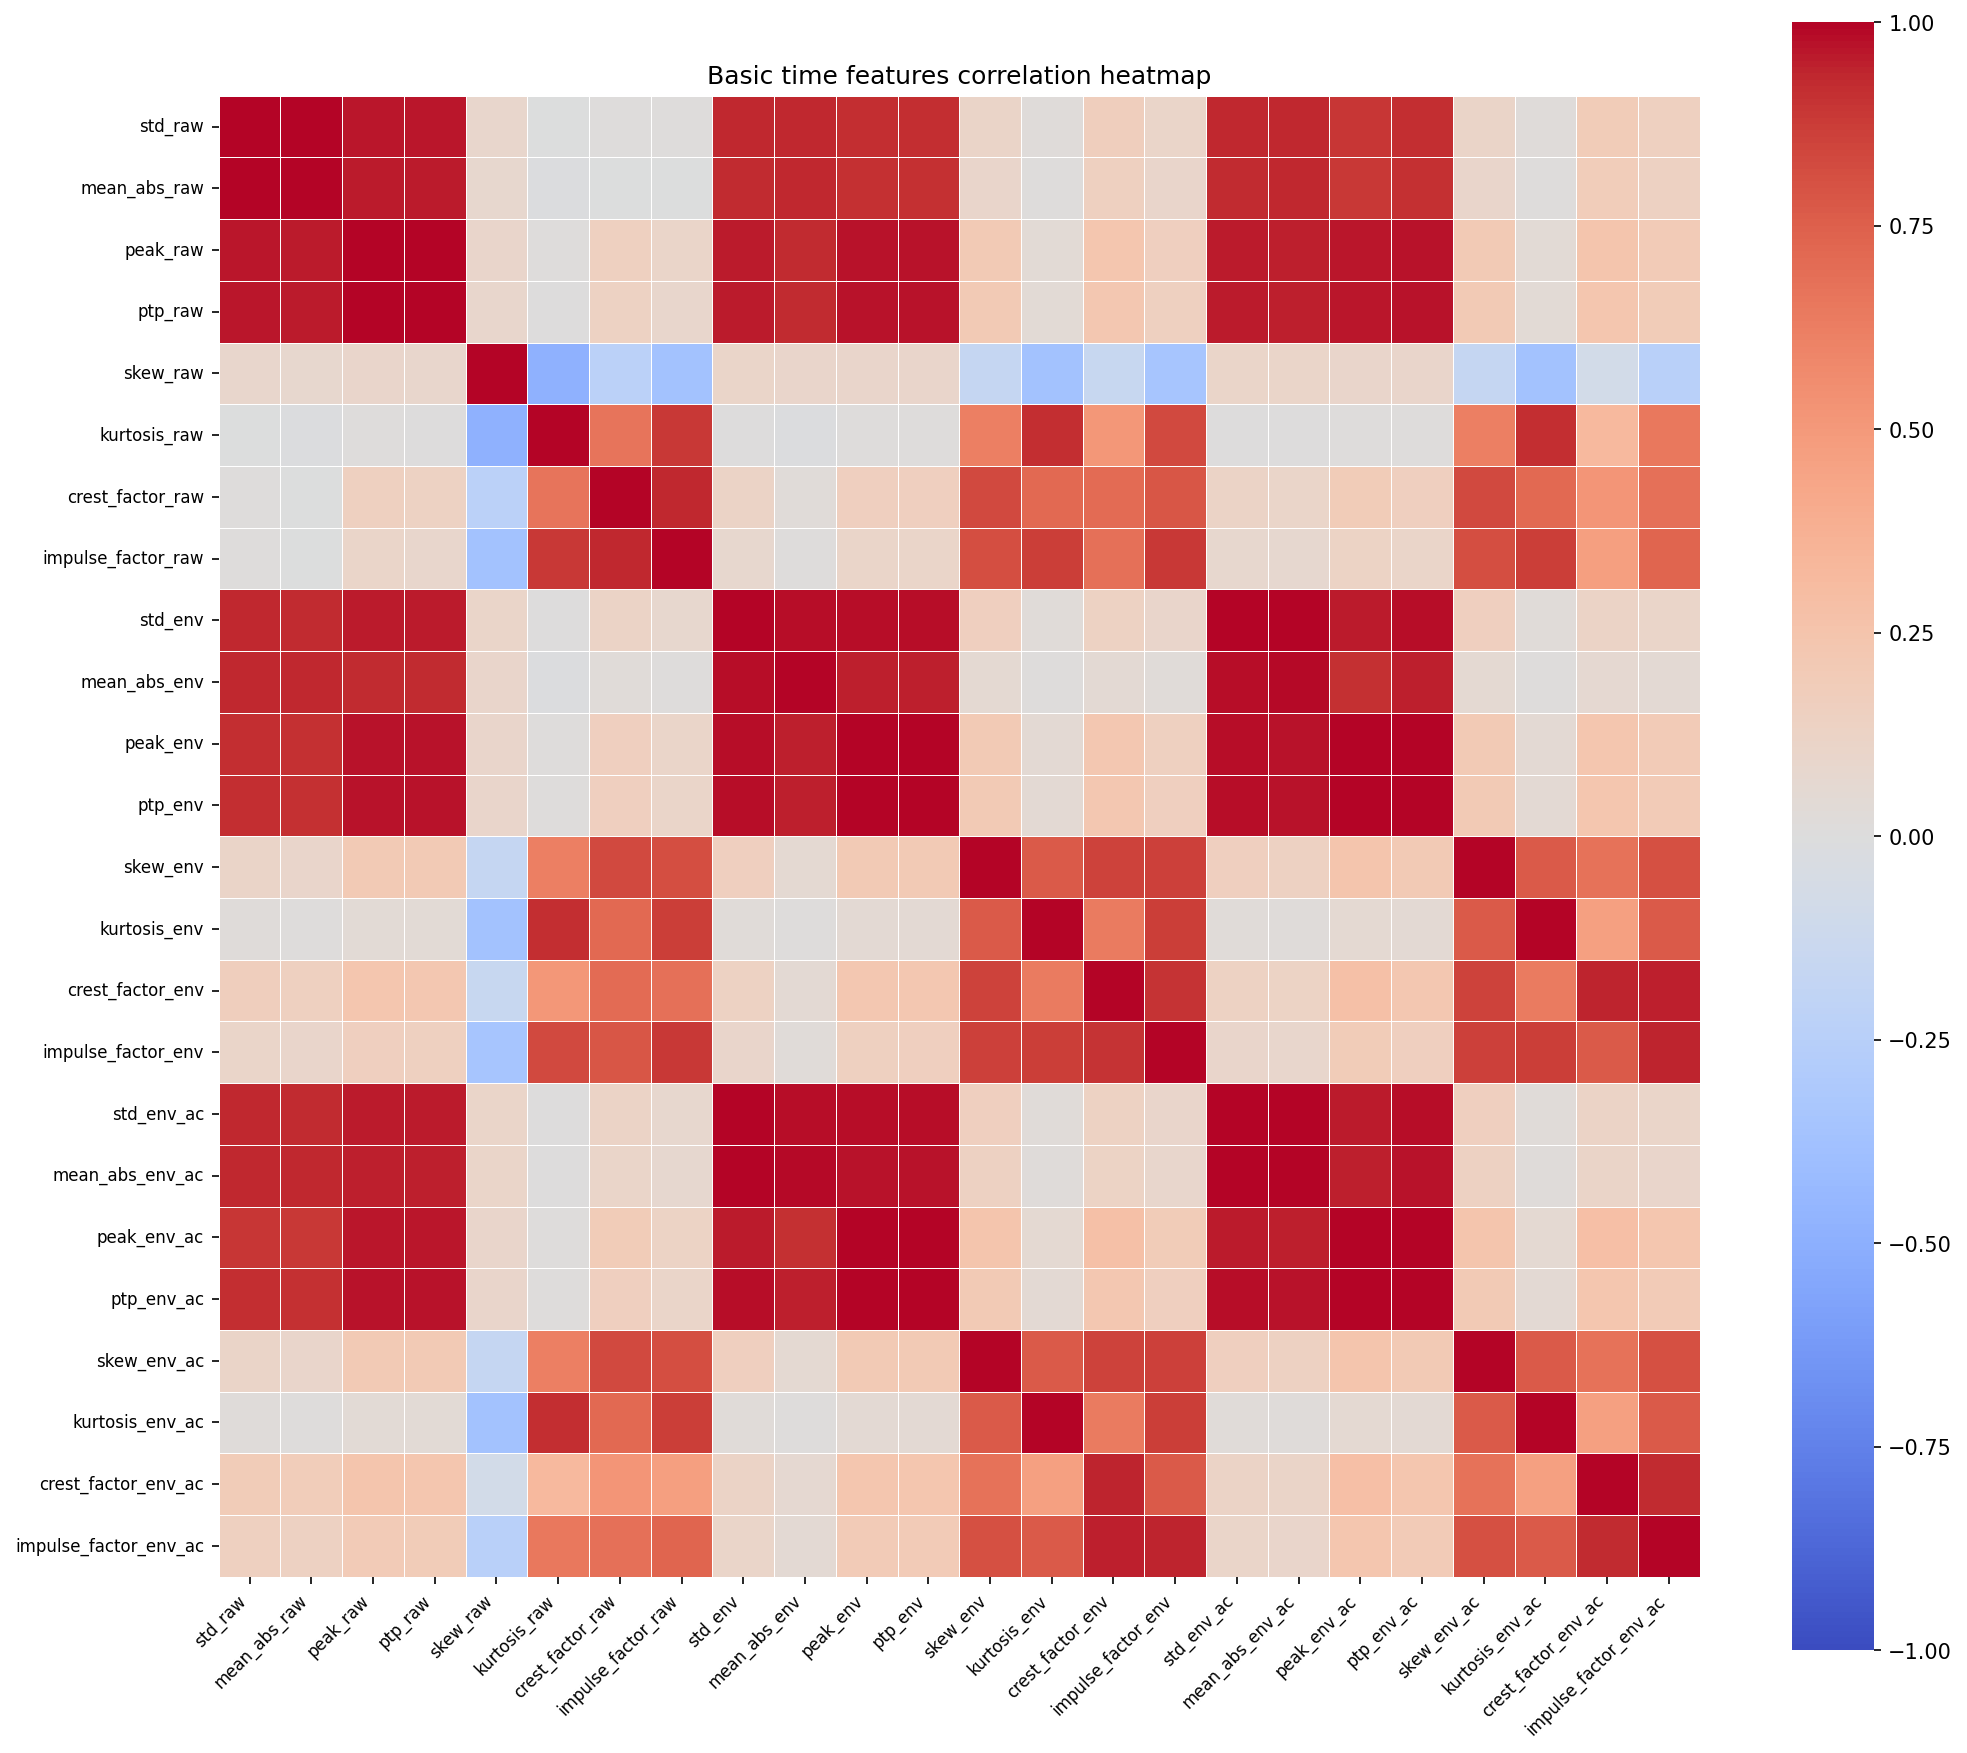

In [ ]:
corr = df_feat2.select_dtypes(include="number").corr(numeric_only=True)

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr,
    cmap="coolwarm", vmin=-1, vmax=1,
    square=True,
    annot=False,               # ключевое: убрать цифры
    linewidths=0.3
)
ax.set_title("Basic time features correlation heatmap")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# 1) Сначала убираем явно избыточные или трудноинтерпретируемые столбцы.
drop_patterns = [
    r"^ptp_",          # Пик-ту-пик часто дублирует peak.
    r"^mean_abs_",     # mean_abs обычно близок к RMS.
    r"_env$",          # Оставляем в основном AC-вариант огибающей.
]

cols_to_drop = []
for c in df_feat2.columns:
    if any(re.search(p, c) for p in drop_patterns):
        cols_to_drop.append(c)

# fixedSpeed лучше убрать, чтобы не подмешивать мета-утечку в модель.
if "fixedSpeed" in df_feat2.columns:
    cols_to_drop.append("fixedSpeed")

df_feat2_reduced = df_feat2.drop(columns=sorted(set(cols_to_drop)), errors="ignore")

print("df_feat2:", df_feat2.shape, "-> reduced:", df_feat2_reduced.shape)
df_feat2_reduced.head()


df_feat2: (5419, 24) -> reduced: (5419, 12)


,std_raw,peak_raw,skew_raw,kurtosis_raw,crest_factor_raw,impulse_factor_raw,std_env_ac,peak_env_ac,skew_env_ac,kurtosis_env_ac,crest_factor_env_ac,impulse_factor_env_ac
0,1.032344,4.982941,0.052800,-0.034327,4.826821,6.043790,0.568204,2.379362,0.409340,-0.338633,4.187510,5.100390
1,1.022207,3.942540,0.096364,-0.188478,3.856889,4.809881,0.574378,2.214535,0.375319,-0.381549,3.855536,4.702198
2,1.051467,3.798938,0.107780,-0.224524,3.612987,4.496685,0.600559,2.178650,0.390425,-0.353579,3.627705,4.422835
3,1.111958,4.738598,0.062603,-0.023162,4.261491,5.342759,0.602327,2.722829,0.398084,-0.356172,4.520514,5.518868
4,1.059690,3.759609,0.116544,-0.265166,3.547838,4.400834,0.612478,2.273952,0.353921,-0.469895,3.712711,4.506188


##### Корреляции

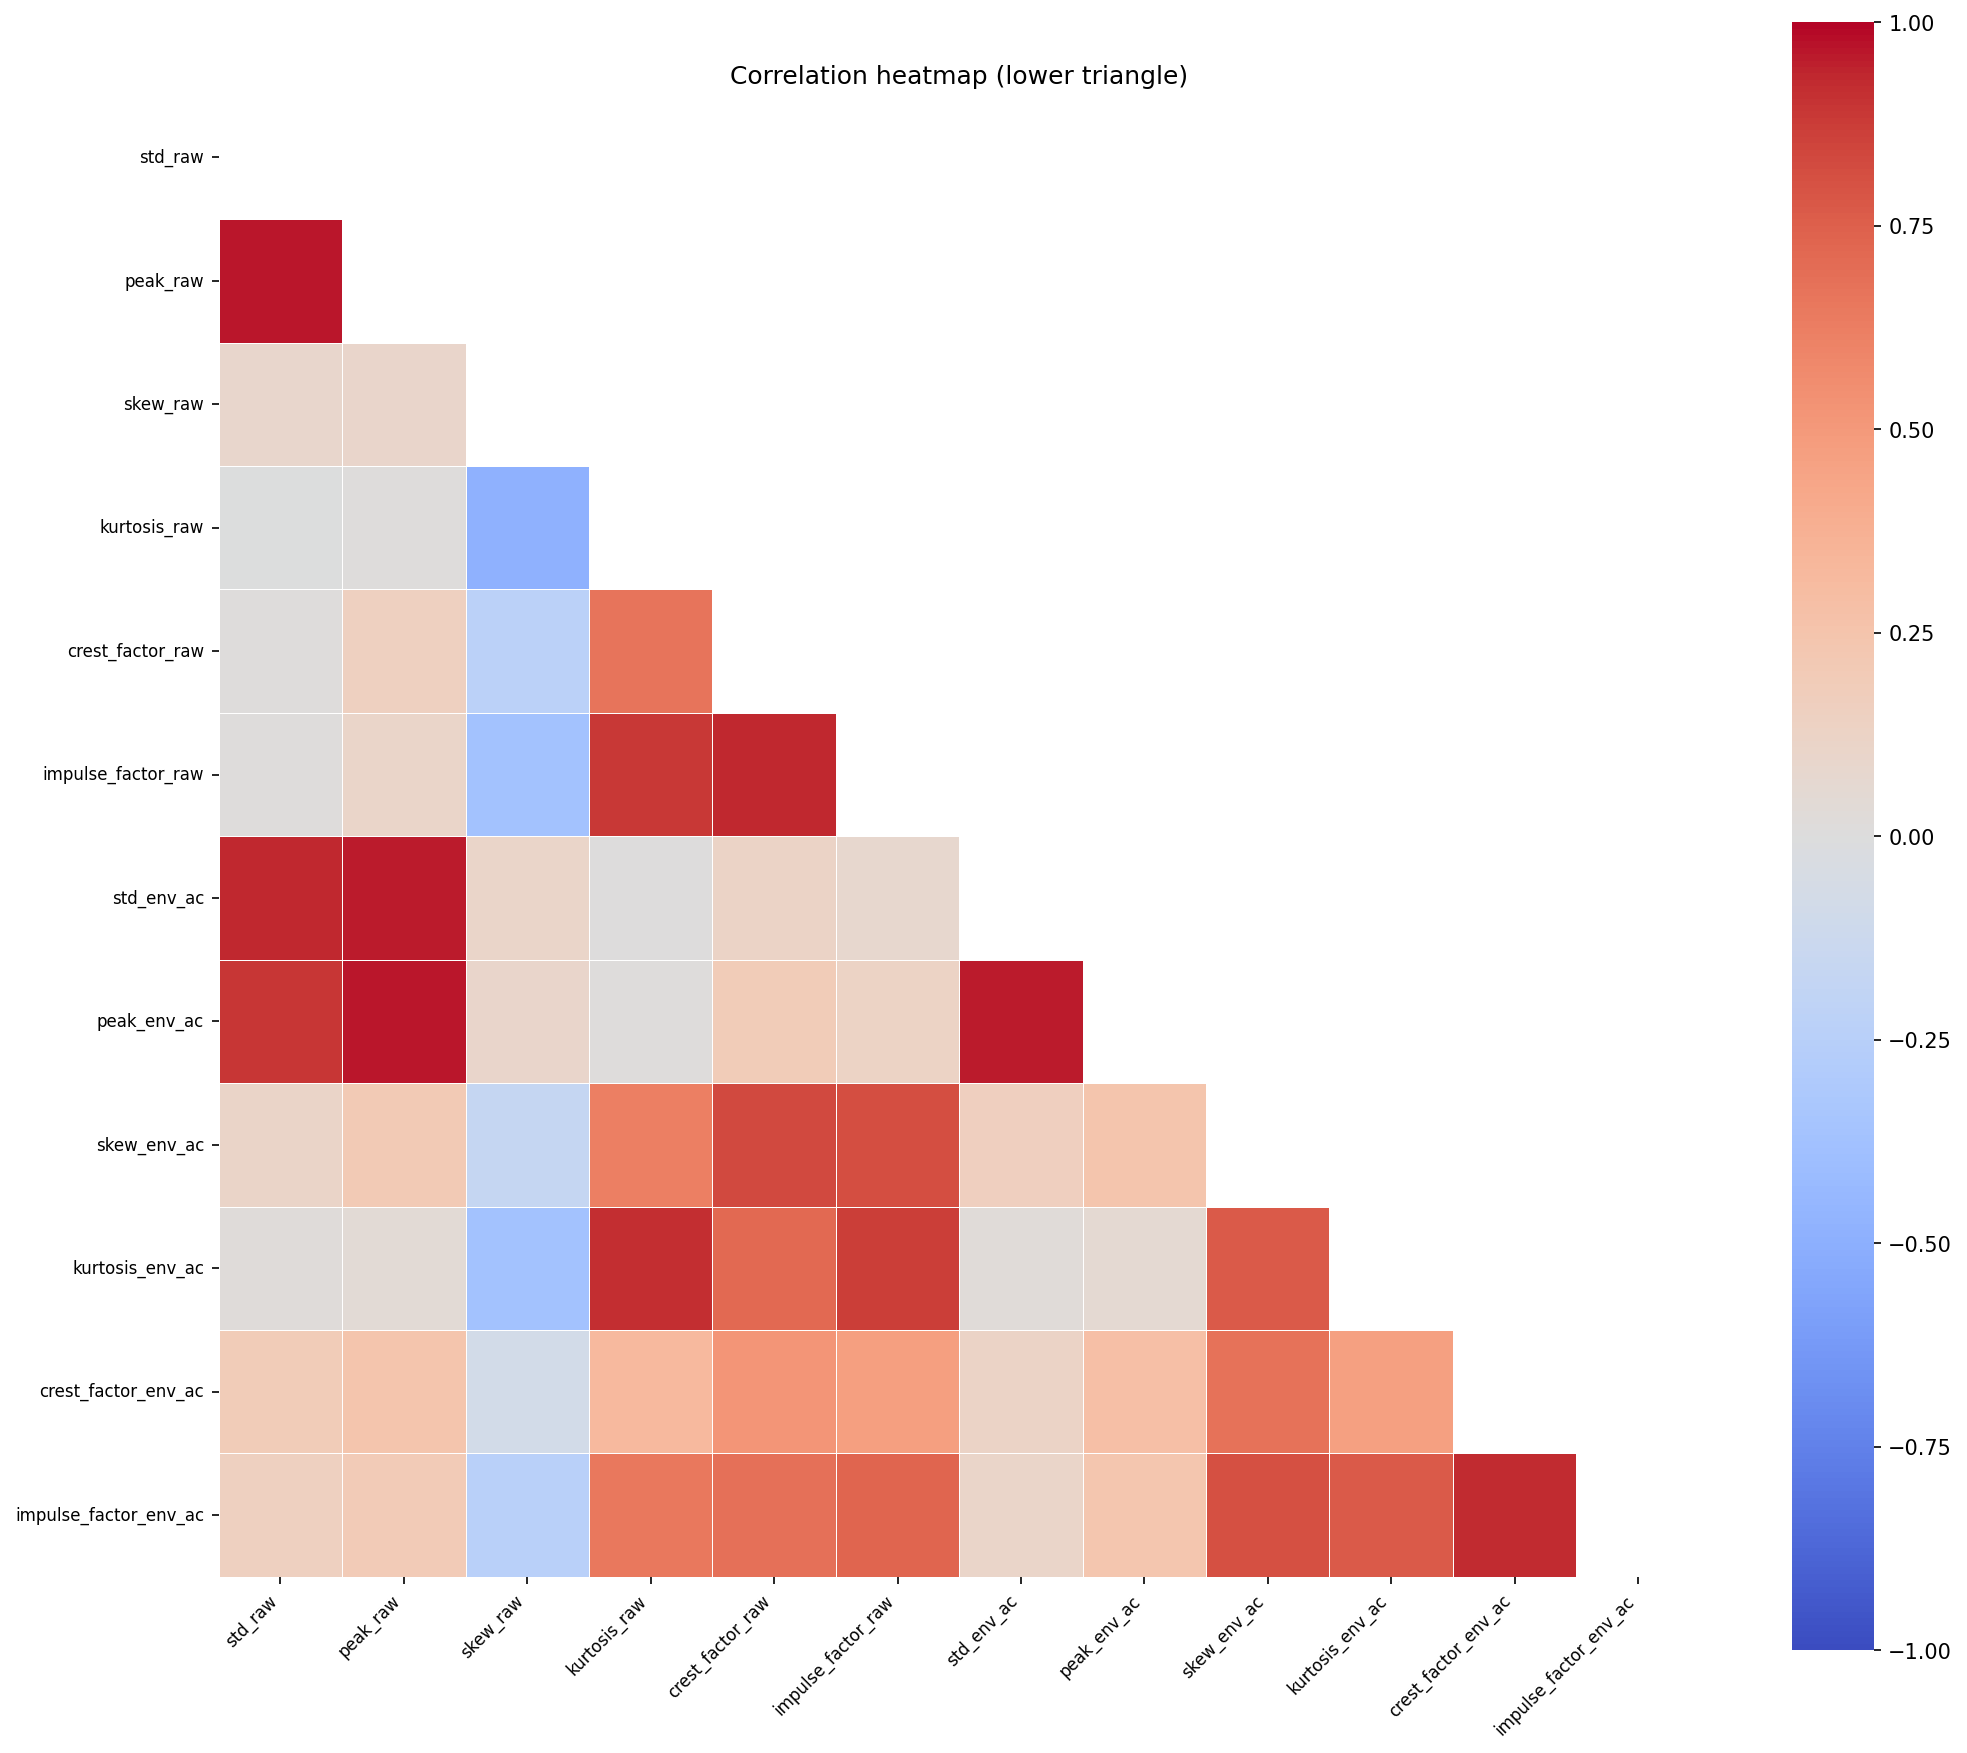

In [ ]:
corr = df_feat2_reduced.select_dtypes(include="number").corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  # верхний треугольник скрыть

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask,
    cmap="coolwarm", vmin=-1, vmax=1,
    square=True,
    annot=False,
    linewidths=0.3
)
ax.set_title("Correlation heatmap (lower triangle)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

#### Энергия около оборотных гармоник

In [ ]:
def raw_harmonic_band_energies(
    row: Any,
    x: np.ndarray,
    fs: float,
    harmonics: Sequence[int] = (1, 2, 3),
    window: Optional[str] = "hann",
) -> dict[str, float]:
    """Считает энергию вокруг оборотных гармоник 1x, 2x и 3x."""
    f, mag = rfft_mag(x, fs, window=window)

    rpm = float(_get_field(row, "RPM", np.nan))
    if not np.isfinite(rpm) or rpm <= 0:
        # Если RPM некорректен, этот блок фичей делаем нулевым.
        return {f"E_{k}x": 0.0 for k in harmonics}

    fr = rpm / 60.0
    hw = auto_half_width_hz(fs, len(x), min_width=0.5, bins=3)

    feats: dict[str, float] = {}
    for k in harmonics:
        feats[f"E_{k}x"] = band_energy_around(f, mag, center_hz=k * fr, half_width_hz=hw)

    # Нормируем на общую энергию спектра, чтобы фичи были устойчивее к масштабу сигнала.
    total_E = float(np.sum(mag ** 2)) + 1e-12
    for k in harmonics:
        feats[f"E_{k}x_rel"] = feats[f"E_{k}x"] / total_E

    feats["fr_hz"] = fr
    feats["fft_bin_hz"] = fs / len(x)
    feats["band_half_width_hz"] = hw
    return feats


#### Пики около частот дефектов на спектре огибающей

In [ ]:
def envelope_fault_peaks(
    row: Any,
    x: np.ndarray,
    fs: float,
    max_harmonics: int = 3,
    window: Optional[str] = "hann",
    env_band: Optional[tuple[float, float]] = None,
) -> dict[str, float]:
    """Ищет пики на спектре огибающей вокруг частот дефектов и их гармоник."""
    # Если полоса не задана, берем ту же эвристику, что и в других блоках огибающей.
    if env_band is None:
        low = max(10.0, 0.10 * fs)
        high = min(0.45 * fs, 0.49 * fs)
        env_band = (low, high)

    env = envelope_hilbert(x, fs, band=env_band)
    env_ac = env - np.mean(env)

    # Спектр огибающей позволяет лучше видеть модуляционные дефектные частоты.
    f_env, mag_env = rfft_mag(env_ac, fs, window=window)
    freqs = characteristic_freqs_hz_from_multiples(row)
    hw = auto_half_width_hz(fs, len(env_ac), min_width=0.5, bins=4)

    feats: dict[str, float] = {}
    nyq = fs / 2.0

    for name, f0 in freqs.items():
        for h in range(1, max_harmonics + 1):
            fh = h * f0
            key = f"peak_{name.lower()}_h{h}"
            if fh <= 0 or fh >= nyq:
                feats[key] = 0.0
            else:
                feats[key] = peak_near(f_env, mag_env, center_hz=fh, half_width_hz=hw)

    peaks = [v for k, v in feats.items() if k.startswith("peak_")]
    feats["sum_fault_peaks"] = float(np.sum(peaks)) if peaks else 0.0

    total_env_E = float(np.sum(mag_env ** 2)) + 1e-12
    feats["sum_fault_peaks_rel"] = feats["sum_fault_peaks"] / np.sqrt(total_env_E)

    feats["env_band_low_hz"] = float(env_band[0])
    feats["env_band_high_hz"] = float(env_band[1])
    feats["env_peak_half_width_hz"] = float(hw)
    return feats


#### Вывод значений энергий и пиков на конкретном примере

In [ ]:
i = 490
row = df_meta.iloc[i]
x = X_signals[int(row.signal_idx)]
fs = float(row.samplingRate)

fe1 = raw_harmonic_band_energies(row, x, fs, harmonics=(1,2,3))
fe2 = envelope_fault_peaks(row, x, fs, max_harmonics=3)

fe_all = {**fe1, **fe2}
# print(len(fe_all))
fe_all

{'E_1x': 0.18734039799418567,
 'E_2x': 0.12683444406488115,
 'E_3x': 0.027421586553480242,
 'E_1x_rel': 0.03567540002304909,
 'E_2x_rel': 0.02415319694610724,
 'E_3x_rel': 0.005221917322885338,
 'fr_hz': 19.366666666666667,
 'fft_bin_hz': 0.3125,
 'band_half_width_hz': 0.9375,
 'peak_ftf_h1': 0.018863073215760723,
 'peak_ftf_h2': 0.011451883625149376,
 'peak_ftf_h3': 0.022348614238775814,
 'peak_bsf_h1': 0.035459477237244984,
 'peak_bsf_h2': 0.07937133845429724,
 'peak_bsf_h3': 0.014723208981733541,
 'peak_bpfi_h1': 0.04157282710974096,
 'peak_bpfi_h2': 0.01017012554698224,
 'peak_bpfi_h3': 0.010132728495117715,
 'peak_bpfo_h1': 0.02483488470118714,
 'peak_bpfo_h2': 0.020436242833704155,
 'peak_bpfo_h3': 0.01148240924317269,
 'peak_fr_h1': 0.1107398417323294,
 'peak_fr_h2': 0.035459477237244984,
 'peak_fr_h3': 0.015065465476750663,
 'sum_fault_peaks': 0.4621115981291916,
 'sum_fault_peaks_rel': np.float64(0.7950630956921148),
 'env_band_low_hz': 512.0,
 'env_band_high_hz': 2304.0,
 'en

#### Добавляем признаки (энергия и пики) df_3

In [ ]:
rows = []
for row in df_meta.itertuples(index=False):
    x = X_signals[int(row.signal_idx)]
    fs = float(row.samplingRate)

    feats = {}
    feats.update(raw_harmonic_band_energies(row, x, fs, harmonics=(1, 2, 3)))
    feats.update(envelope_fault_peaks(row, x, fs, max_harmonics=3))

    # Метаполя добавляем минимально, только для анализа и дальнейшей фильтрации.
    feats["fixedSpeed"] = int(_get_field(row, "fixedSpeed", 0))
    feats["faultOrigin"] = str(_get_field(row, "faultOrigin", ""))
    feats["label"] = int(_get_field(row, "label", -999))

    rows.append(feats)

df_feat3 = pd.DataFrame(rows)

# one-hot по faultOrigin делаем здесь, а нужность его оставлять решаем на шаге отбора фичей.
df_feat3 = pd.get_dummies(df_feat3, columns=["faultOrigin"], drop_first=False, dtype="int8")

df_feat3.head()


,E_1x,E_2x,E_3x,E_1x_rel,E_2x_rel,E_3x_rel,fr_hz,fft_bin_hz,band_half_width_hz,peak_ftf_h1,...,sum_fault_peaks,sum_fault_peaks_rel,env_band_low_hz,env_band_high_hz,env_peak_half_width_hz,fixedSpeed,label,faultOrigin_DS,faultOrigin_FS,faultOrigin_Upper
0,0.061653,0.036506,0.004278,0.004836,0.002863,0.000336,19.366667,0.3125,0.9375,0.105691,...,2.420819,1.227807,512.0,2304.0,1.25,1,3,1,0,0
1,0.135412,0.071942,0.008094,0.010782,0.005728,0.000645,19.366667,0.3125,0.9375,0.048320,...,2.321862,1.169304,512.0,2304.0,1.25,1,3,1,0,0
2,0.157408,0.020209,0.005928,0.011827,0.001518,0.000445,19.366667,0.3125,0.9375,0.065999,...,2.421318,1.172143,512.0,2304.0,1.25,1,3,1,0,0
3,0.289505,0.006816,0.006283,0.019830,0.000467,0.000430,19.366667,0.3125,0.9375,0.059061,...,2.409769,1.158178,512.0,2304.0,1.25,1,3,1,0,0
4,0.118401,0.007812,0.003492,0.008851,0.000584,0.000261,19.366667,0.3125,0.9375,0.060917,...,2.485851,1.175958,512.0,2304.0,1.25,1,3,1,0,0


##### Убираем избыточные и плохо масштабируемые признаки

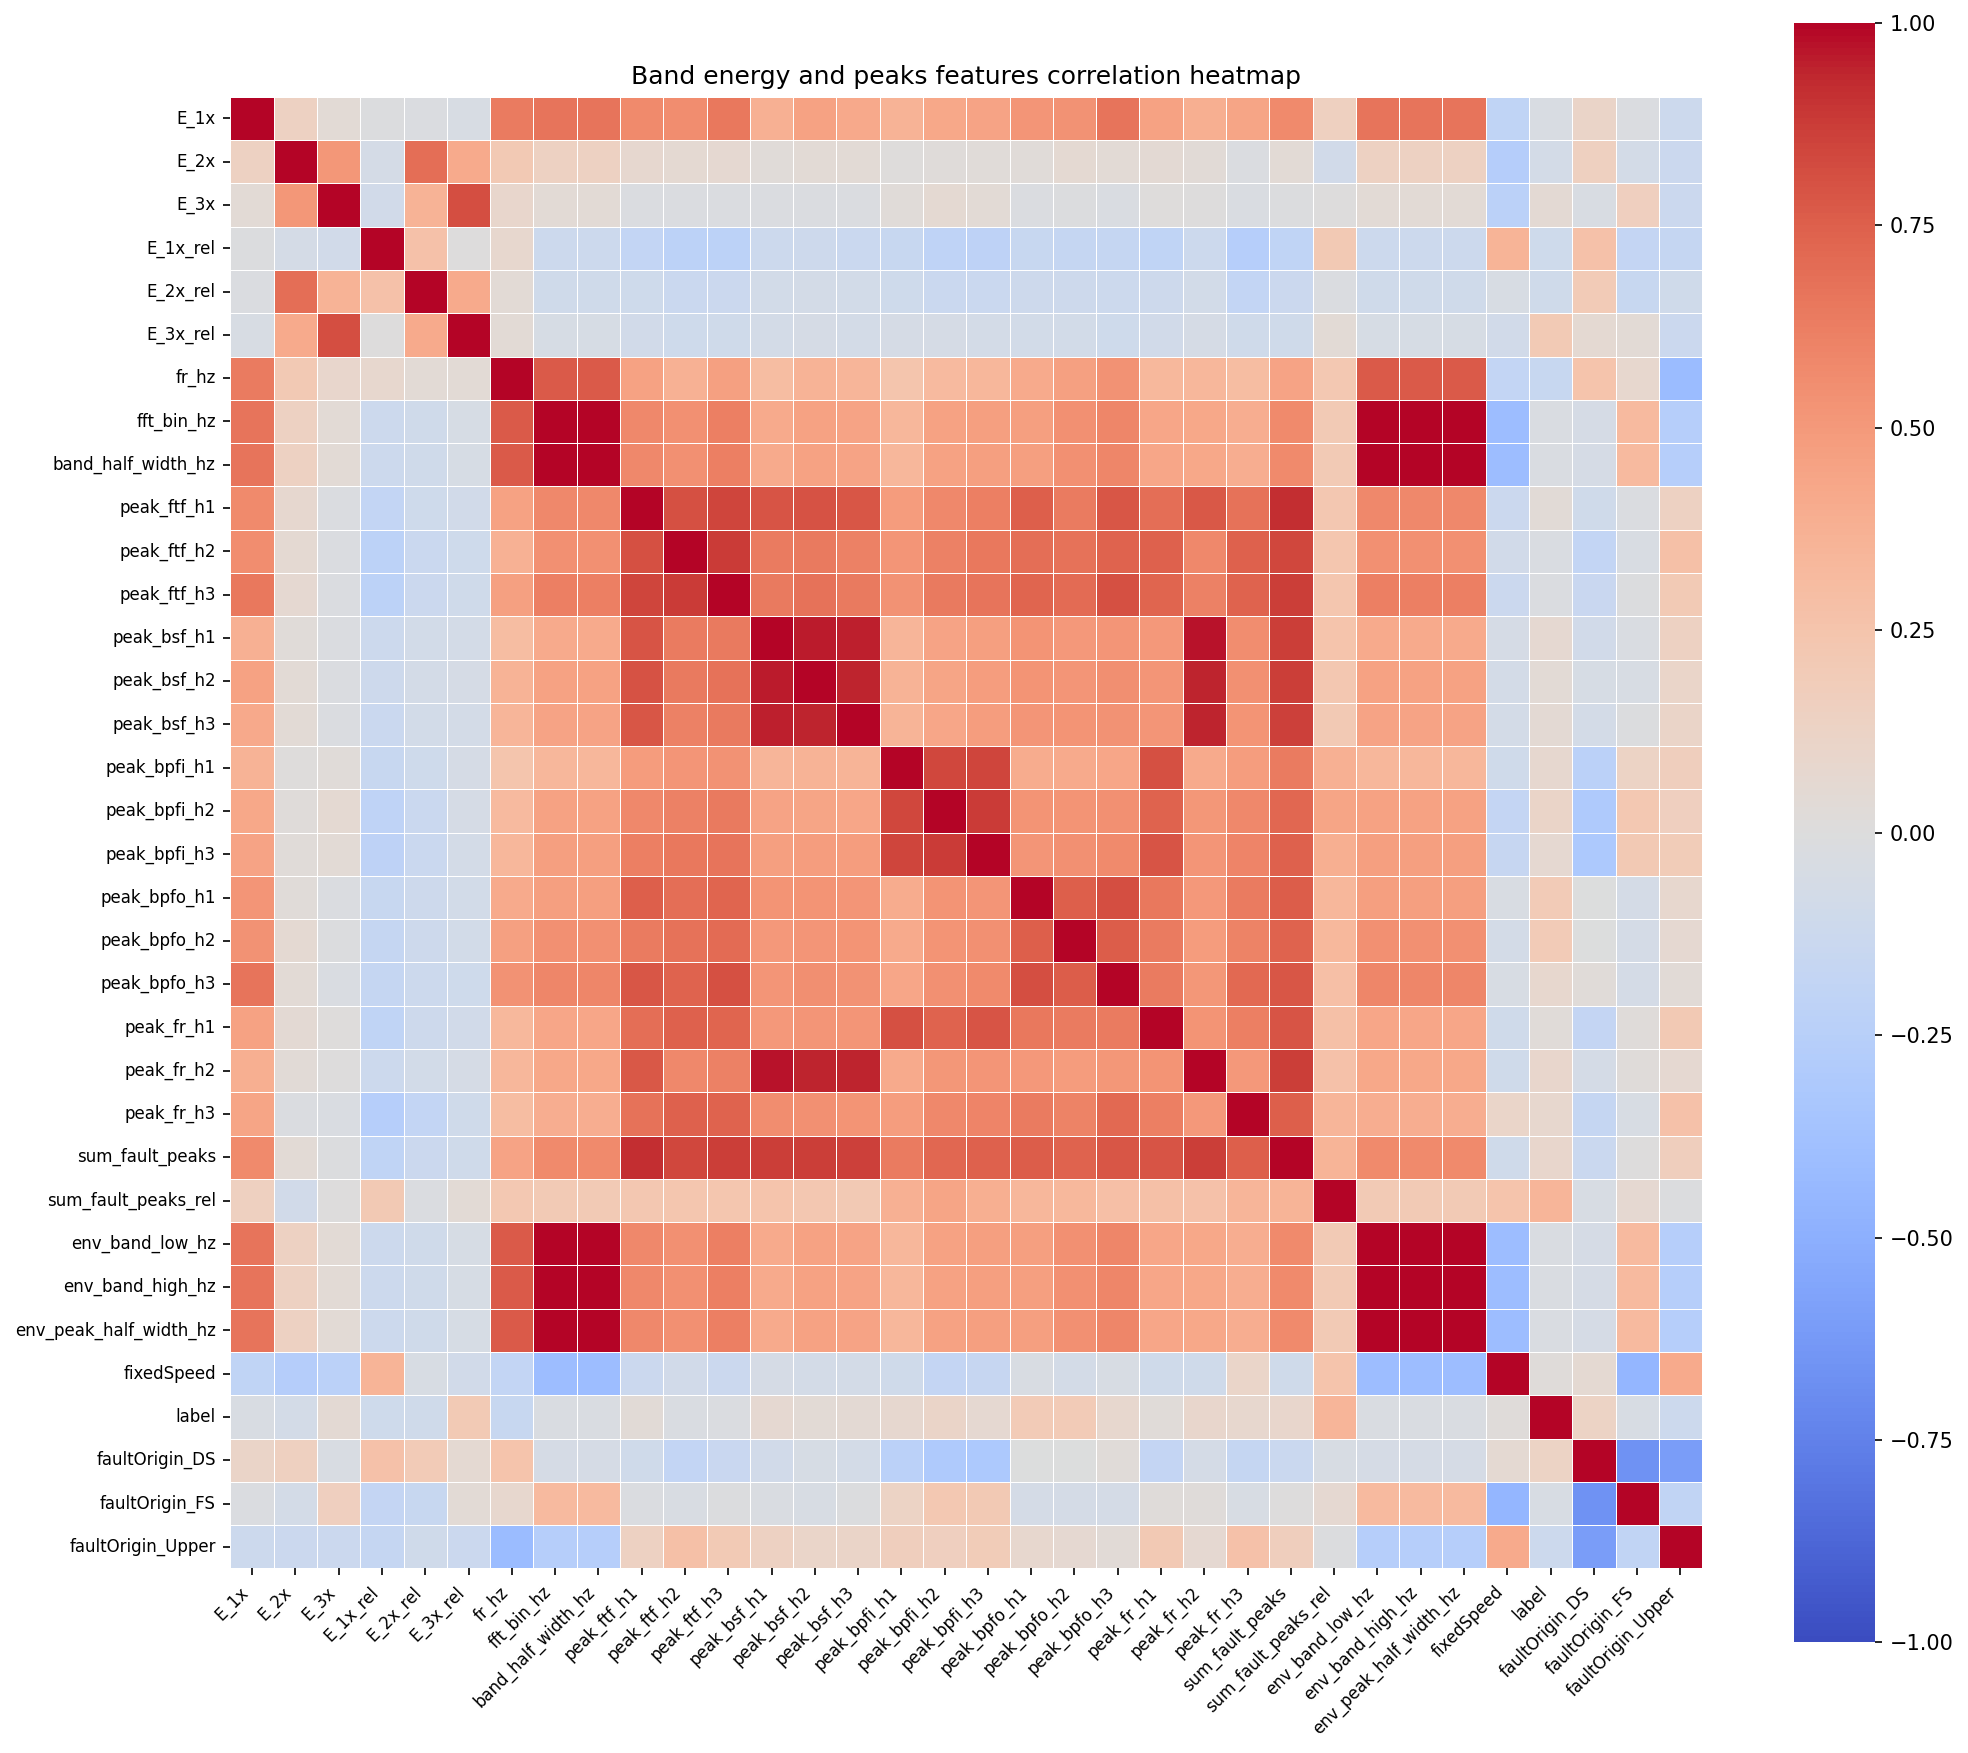

In [ ]:
num_bool = df_feat3.select_dtypes(include=["number", "bool"]).copy()

# bool -> 0/1
bool_cols = num_bool.select_dtypes(include=["bool"]).columns
num_bool[bool_cols] = num_bool[bool_cols].astype("int8")

corr = df_feat3.select_dtypes(include="number").corr(numeric_only=True)

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr,
    cmap="coolwarm", vmin=-1, vmax=1,
    square=True,
    annot=False,
    linewidths=0.3
)
ax.set_title("Band energy and peaks features correlation heatmap")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
cols_to_drop = []

# 1) Абсолютные энергии убираем, оставляя только относительные варианты.
for c in df_feat3.columns:
    if re.match(r"^E_[123]x$", c):
        cols_to_drop.append(c)

# 2) Технические поля нужны для отладки, но не для безового обучения.
tech_cols = [
    "fft_bin_hz", "band_half_width_hz",
    "env_band_low_hz", "env_band_high_hz", "env_peak_half_width_hz"
]
cols_to_drop += [c for c in tech_cols if c in df_feat3.columns]

# 3) Третьи гармоники пиков исключаем как наименее стабильные.
cols_to_drop += [c for c in df_feat3.columns if re.search(r"_h3$", c)]

# 4) Метаполя лучше убрать, чтобы не давать модели короткие пути к ответу.
if "fixedSpeed" in df_feat3.columns:
    cols_to_drop.append("fixedSpeed")

# Все колонки one-hot по faultOrigin убираем из базового набора.
cols_to_drop += [c for c in df_feat3.columns if c.startswith("faultOrigin_")]

df_feat3_reduced = df_feat3.drop(columns=sorted(set(cols_to_drop)), errors="ignore")

print("df_feat3:", df_feat3.shape, "-> reduced:", df_feat3_reduced.shape)
df_feat3_reduced.head()


df_feat3: (5419, 34) -> reduced: (5419, 17)


,E_1x_rel,E_2x_rel,E_3x_rel,fr_hz,peak_ftf_h1,peak_ftf_h2,peak_bsf_h1,peak_bsf_h2,peak_bpfi_h1,peak_bpfi_h2,peak_bpfo_h1,peak_bpfo_h2,peak_fr_h1,peak_fr_h2,sum_fault_peaks,sum_fault_peaks_rel,label
0,0.004836,0.002863,0.000336,19.366667,0.105691,0.059264,0.163246,0.073589,0.041171,0.020707,0.358263,0.528714,0.095468,0.163246,2.420819,1.227807,3
1,0.010782,0.005728,0.000645,19.366667,0.048320,0.052919,0.153436,0.075828,0.068637,0.024198,0.341201,0.561588,0.089543,0.153436,2.321862,1.169304,3
2,0.011827,0.001518,0.000445,19.366667,0.065999,0.071934,0.161622,0.098779,0.057401,0.013876,0.345753,0.560819,0.101486,0.161622,2.421318,1.172143,3
3,0.019830,0.000467,0.000430,19.366667,0.059061,0.063417,0.170233,0.068816,0.049544,0.025096,0.347943,0.596427,0.102867,0.170233,2.409769,1.158178,3
4,0.008851,0.000584,0.000261,19.366667,0.060917,0.040936,0.185665,0.082379,0.020735,0.014228,0.390425,0.591588,0.093894,0.185665,2.485851,1.175958,3


##### Корреляции

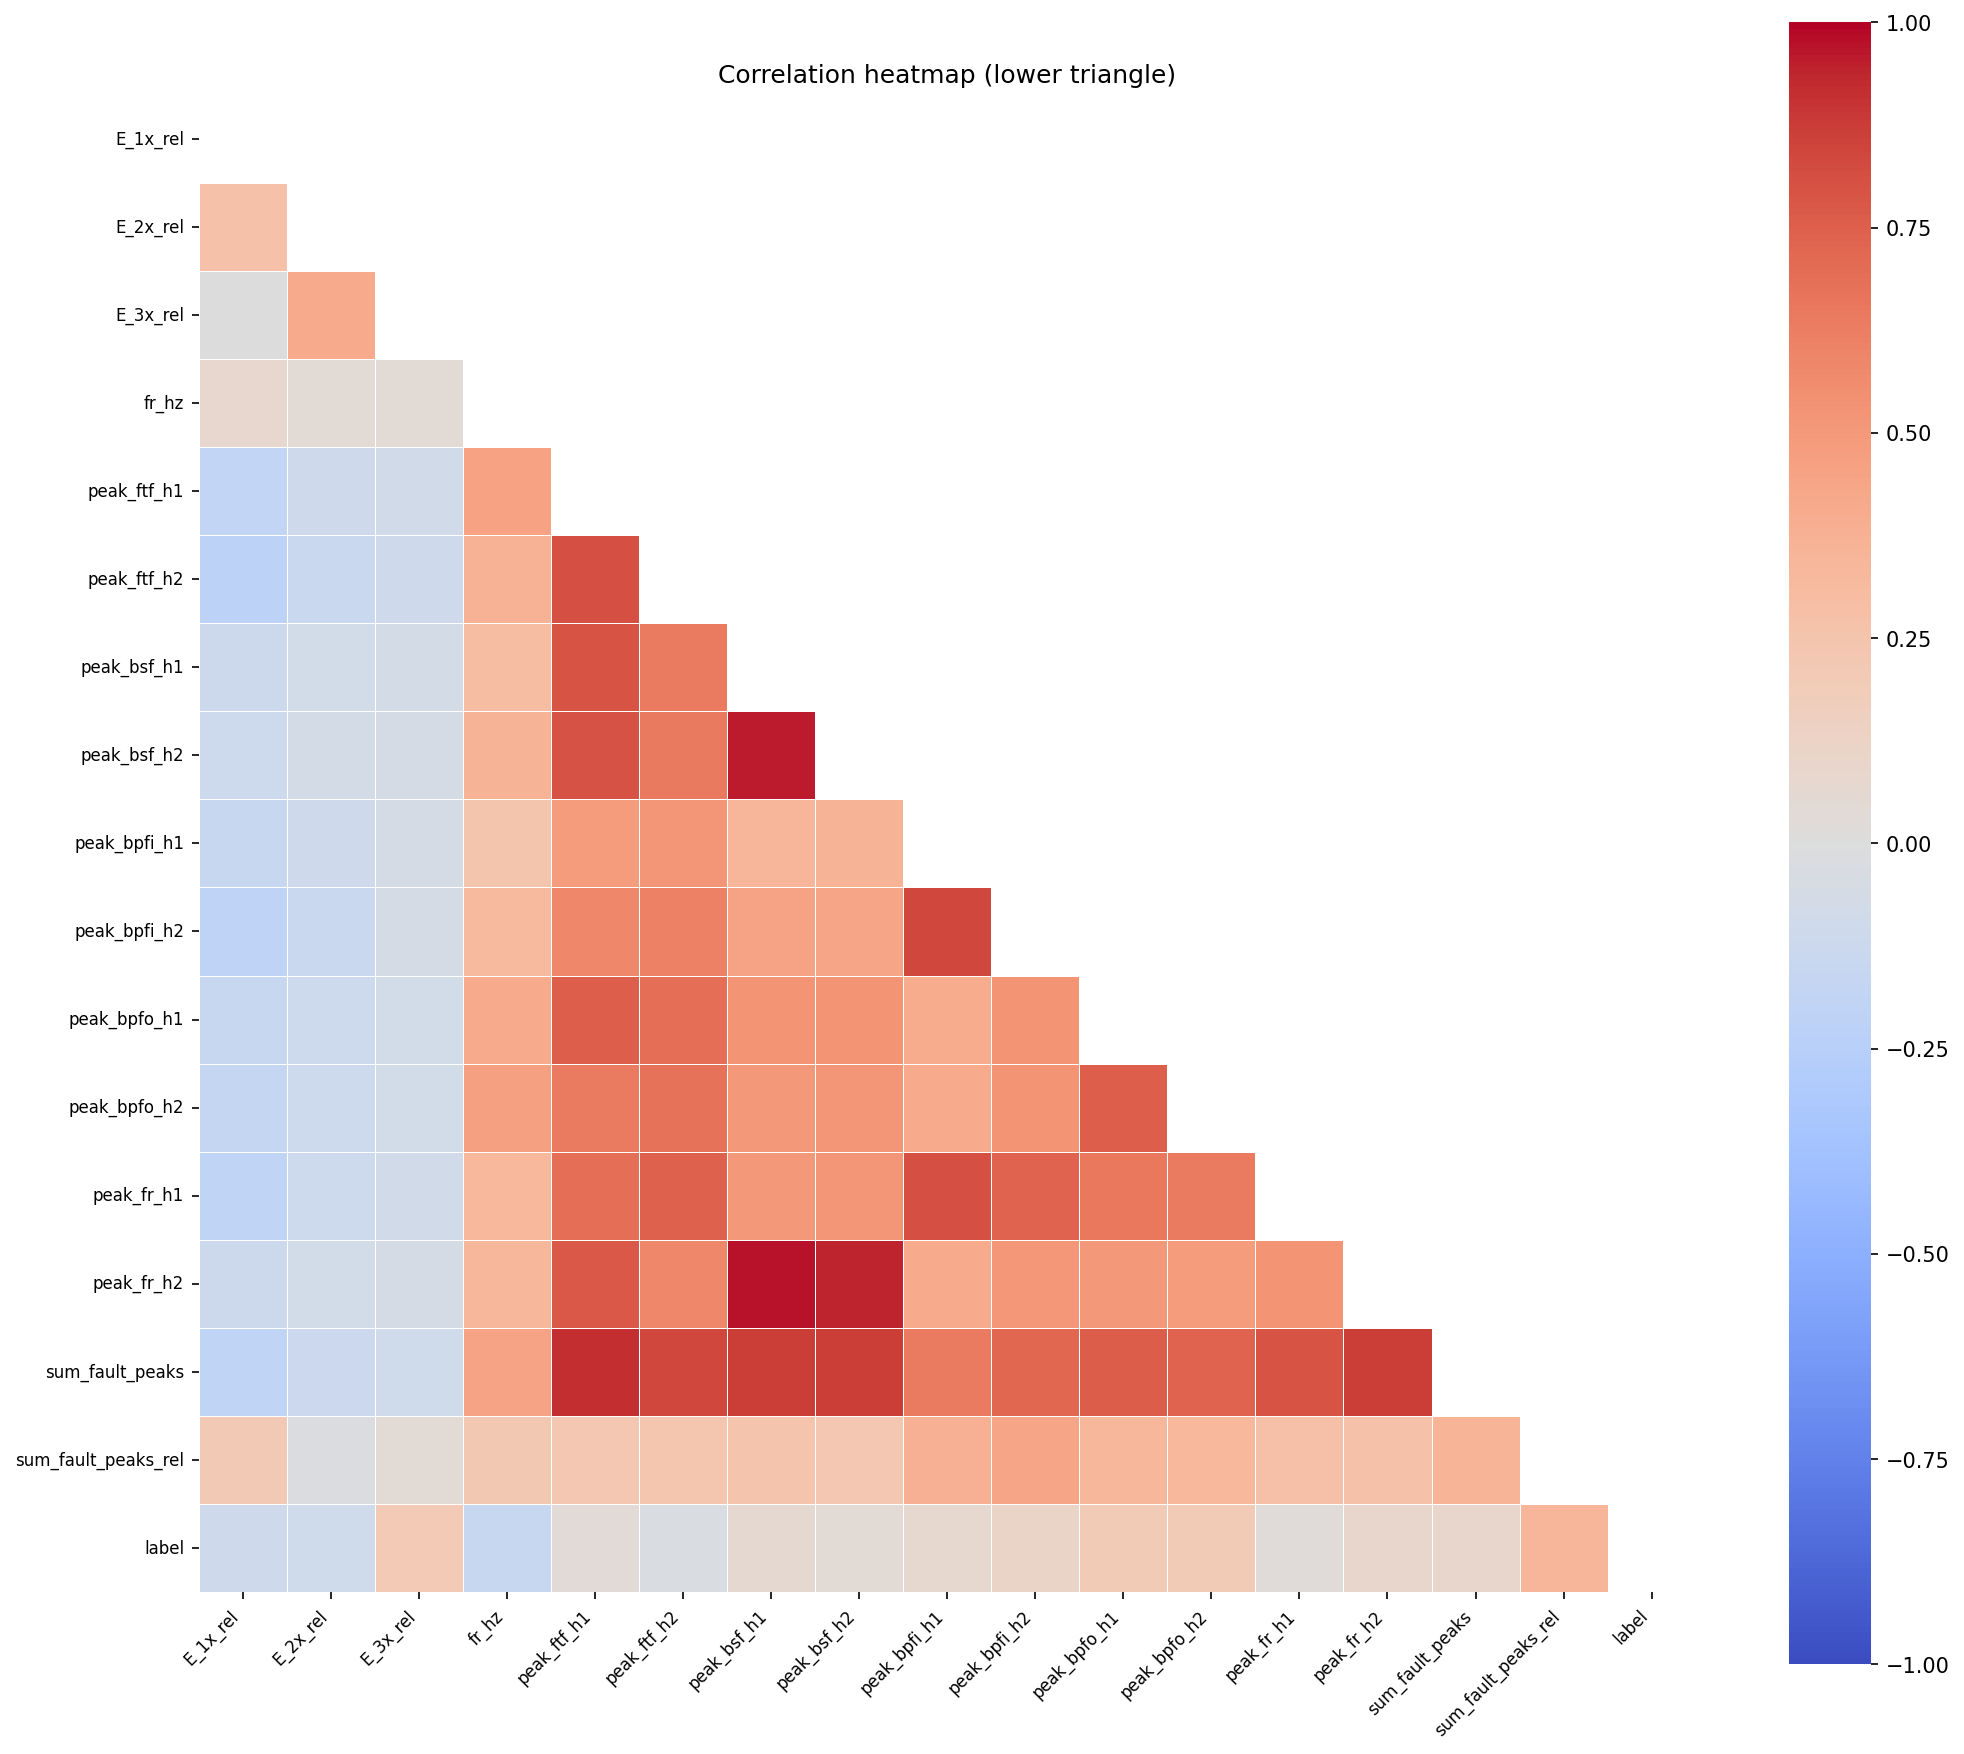

In [ ]:
corr = df_feat3_reduced.select_dtypes(include="number").corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  # верхний треугольник скрыть

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask,
    cmap="coolwarm", vmin=-1, vmax=1,
    square=True,
    annot=False,
    linewidths=0.3
)
ax.set_title("Correlation heatmap (lower triangle)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

#### Очистка от сильно скоррелированных признаков и объединение в один DF


In [ ]:
def drop_highly_correlated(
    df: pd.DataFrame,
    threshold: float = 0.98,
    exclude: Sequence[str] = ("label",),
) -> tuple[pd.DataFrame, list[str]]:
    """Удаляет сильно коррелирующие числовые признаки выше заданного порога."""
    num = df.select_dtypes(include=["number", "bool"]).copy()
    for c in exclude:
        if c in num.columns:
            num = num.drop(columns=[c])

    corr = num.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop, errors="ignore"), to_drop

# Финально снижаем избыточную корреляцию внутри блоков признаков.
df_feat2_final, dropped2 = drop_highly_correlated(df_feat2_reduced, threshold=0.98, exclude=("label",))
df_feat3_final, dropped3 = drop_highly_correlated(df_feat3_reduced, threshold=0.98, exclude=("label",))

print("Dropped df_feat2 columns:", len(dropped2))
print("Dropped df_feat3 columns:", len(dropped3))
print("df_feat:", df_feat.shape)
print("df_feat2_final:", df_feat2_final.shape)
print("df_feat3_final:", df_feat3_final.shape)


Dropped df_feat2 columns: 0
Dropped df_feat3 columns: 0
df_feat: (5419, 2)
df_feat2_final: (5419, 12)
df_feat3_final: (5419, 17)


##### Объединение полученных DF в один


In [ ]:
# Для надежного merge явно добавляем сквозной meta_row_id во все блоки.
A = df_feat.reset_index(drop=True).copy()
B = df_feat2_final.reset_index(drop=True).copy()
C = df_feat3_final.reset_index(drop=True).copy()
M = df_meta_high.reset_index(drop=True).copy()

for d in [A, B, C, M]:
    d["meta_row_id"] = np.arange(len(d), dtype=int)

if not (len(A) == len(B) == len(C) == len(M)):
    raise RuntimeError(f"Size mismatch: A={len(A)}, B={len(B)}, C={len(C)}, M={len(M)}")

meta_cols = ["meta_row_id", "case_id", "split", "placement", "time", "samplingRate", "RPM", "label"]

df_all = (
    C.merge(B, on="meta_row_id", how="inner", validate="one_to_one")
     .merge(A, on="meta_row_id", how="inner", validate="one_to_one")
     .merge(M[meta_cols], on="meta_row_id", how="left", validate="one_to_one", suffixes=("", "_meta"))
)

if "label_meta" in df_all.columns:
    same_label = (df_all["label"].astype(int) == df_all["label_meta"].astype(int)).mean()
    print("label equals meta label:", same_label)
    df_all = df_all.drop(columns=["label_meta"], errors="ignore")

print("df_all shape before label filter:", df_all.shape)
print("label distribution before filter:")
display(df_all["label"].value_counts().sort_index())


label equals meta label: 1.0
df_all shape before label filter: (5419, 38)
label distribution before filter:


,count
label,
0,4775
1,214
2,23
3,407


## Обучение моделей

В этом блоке сравниваются модели: **RandomForest**, **GradientBoosting**, **XGBoost**, **CatBoost**.


In [ ]:
# Подготовка baseline-признаков и целевой переменной.
target_col = "label"
keep_labels = [0, 1, 2, 3]

df_model = df_all[df_all[target_col].isin(keep_labels)].copy()

# Case 11 оставляем отдельно (подтвержденная несоосность),
# чтобы не смешивать его с основной baseline-валидацией.
case_id_str = df_model["case_id"].astype(str).str.strip()
df_case11_holdout = df_model[case_id_str == "11"].copy()
df_model = df_model[case_id_str != "11"].copy().reset_index(drop=True)

leak_cols = [
    "meta_row_id",
    "case_id", "case_id_int", "split", "time", "source_file",
    "fromDate", "toDate", "faultType", "faultOrigin",
    "assetDescription", "assetName", "unit", "id", "bearing",
    "placement",
]
leak_cols = [c for c in leak_cols if c in df_model.columns]

X_base = df_model.drop(columns=leak_cols + [target_col], errors="ignore").copy()
y_base = df_model[target_col].astype(int).copy()

X_base = X_base.select_dtypes(include=["number", "bool"]).copy()
X_base = X_base.replace([np.inf, -np.inf], np.nan)
X_base = X_base.fillna(X_base.median(numeric_only=True))

const_cols = X_base.columns[X_base.nunique(dropna=False) <= 1].tolist()
if const_cols:
    X_base = X_base.drop(columns=const_cols)

groups_base = (
    df_model["case_id"].astype(str).str.strip()
    + "_"
    + df_model["placement"].astype(str).str.strip()
)

print("X_base shape:", X_base.shape)
print("y_base shape:", y_base.shape)
print("Количество уникальных групп:", groups_base.nunique())
print("Размер holdout case11:", df_case11_holdout.shape)
print("Распределение классов (0..3):")
display(y_base.value_counts().sort_index())
display(X_base.iloc[0])


X_base shape: (5127, 32)
y_base shape: (5127,)
Количество уникальных групп: 13
Размер holdout case11: (292, 38)
Распределение классов (0..3):


,count
label,
0,4483
1,214
2,23
3,407


,0
E_1x_rel,0.004836
E_2x_rel,0.002863
E_3x_rel,0.000336
fr_hz,19.366667
peak_ftf_h1,0.105691
peak_ftf_h2,0.059264
peak_bsf_h1,0.163246
peak_bsf_h2,0.073589
peak_bpfi_h1,0.041171
peak_bpfi_h2,0.020707


#### Вспомогательные функции для обучения

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
UNDERSAMPLE_ZERO = True
ZERO_TO_FAULT_RATIO = 3.0

FOLD_SUMMARY_COLUMNS = [
    "model",
    "fold",
    "macro_f1_present_labels",
    "labels_in_test",
    "train_classes",
    "support1_test",
    "support2_test",
    "support3_test",
    "recall1",
    "recall2",
    "recall3",
    "train_size_used",
    "test_size",
]


def build_model_factories(random_state: int = RANDOM_STATE) -> dict[str, Callable[[int], Any]]:
    """Возвращает фабрики моделей для единого цикла обучения."""
    return {
        "RandomForest": lambda n_classes: RandomForestClassifier(
            n_estimators=500,
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),
        "GradientBoosting": lambda n_classes: GradientBoostingClassifier(random_state=random_state),
        "XGBoost": lambda n_classes: XGBClassifier(
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            n_estimators=700,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=3,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=random_state,
            n_jobs=-1,
            tree_method="hist",
        ),
        "CatBoost": lambda n_classes: CatBoostClassifier(
            loss_function="MultiClass",
            classes_count=n_classes,
            iterations=900,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=4.0,
            random_seed=random_state,
            verbose=False,
        ),
    }


def undersample_zero_train(
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    ratio: float = ZERO_TO_FAULT_RATIO,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.Series]:
    """Случайно уменьшает количество объектов класса 0 в train для снижения дисбаланса."""
    Xtr = Xtr.copy()
    ytr = ytr.copy()

    idx0 = ytr[ytr == 0].index
    idxf = ytr[ytr != 0].index

    n0 = len(idx0)
    nf = len(idxf)
    keep0 = int(min(n0, max(1, round(ratio * nf))))

    if keep0 >= n0:
        return Xtr, ytr

    rng = np.random.RandomState(random_state)
    keep0_idx = rng.choice(idx0.to_numpy(), size=keep0, replace=False)
    keep_idx = np.concatenate([keep0_idx, idxf.to_numpy()])
    rng.shuffle(keep_idx)

    return Xtr.loc[keep_idx], ytr.loc[keep_idx]


def _to_1d_pred(pred_raw: Any) -> np.ndarray:
    """Приводит предсказания к одномерному массиву классов."""
    arr = np.asarray(pred_raw)
    if arr.ndim == 2 and arr.shape[1] > 1:
        return arr.argmax(axis=1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    return arr.reshape(-1)


def fit_predict_model(
    *,
    model_name: str,
    model_factory: Callable[[int], Any],
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    Xte: pd.DataFrame,
) -> tuple[np.ndarray, list[int]]:
    """Обучает модель и возвращает предсказания в исходных метках классов."""
    train_classes = np.sort(ytr.unique())
    model = model_factory(len(train_classes))

    if model_name in {"XGBoost", "CatBoost"}:
        enc = {int(c): i for i, c in enumerate(train_classes)}
        dec = {i: int(c) for i, c in enumerate(train_classes)}

        ytr_enc = ytr.map(enc).astype(int)
        sw = compute_sample_weight(class_weight="balanced", y=ytr_enc)
        model.fit(Xtr, ytr_enc, sample_weight=sw)

        pred_enc = _to_1d_pred(model.predict(Xte)).astype(int)
        pred = np.array([dec.get(int(p), int(train_classes[0])) for p in pred_enc], dtype=int)

    elif model_name == "GradientBoosting":
        sw = compute_sample_weight(class_weight="balanced", y=ytr)
        model.fit(Xtr, ytr, sample_weight=sw)
        pred = _to_1d_pred(model.predict(Xte)).astype(int)

    else:
        model.fit(Xtr, ytr)
        pred = _to_1d_pred(model.predict(Xte)).astype(int)

    return pred, [int(v) for v in train_classes.tolist()]


def collect_fold_metrics(
    *,
    scenario: str,
    model_name: str,
    fold: int,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    train_classes: Sequence[int],
    train_size: int,
    test_size: int,
) -> dict[str, Any]:
    """Формирует строку fold-метрик в требуемом компактном формате."""
    labels_present = sorted(np.unique(y_true).tolist())

    row: dict[str, Any] = {
        "scenario": scenario,
        "model": model_name,
        "fold": fold,
        "macro_f1_present_labels": f1_score(
            y_true, y_pred, labels=labels_present, average="macro", zero_division=0
        ),
        "labels_in_test": labels_present,
        "train_classes": list(train_classes),
        "support1_test": int((y_true == 1).sum()),
        "support2_test": int((y_true == 2).sum()),
        "support3_test": int((y_true == 3).sum()),
        "recall1": float((y_pred[y_true == 1] == 1).mean()) if int((y_true == 1).sum()) > 0 else np.nan,
        "recall2": float((y_pred[y_true == 2] == 2).mean()) if int((y_true == 2).sum()) > 0 else np.nan,
        "recall3": float((y_pred[y_true == 3] == 3).mean()) if int((y_true == 3).sum()) > 0 else np.nan,
        "train_size_used": train_size,
        "test_size": test_size,
    }
    return row


def fold_summary_view(df: pd.DataFrame) -> pd.DataFrame:
    """Возвращает fold-summary только с согласованным минимальным набором колонок."""
    return df[FOLD_SUMMARY_COLUMNS].copy()


def summarize_models(df: pd.DataFrame, labels_eval: Sequence[int]) -> pd.DataFrame:
    """Строит компактный summary по моделям: f1_mean и recall*_mean по доступным классам."""
    agg: dict[str, tuple[str, str]] = {
        "macro_f1_mean": ("macro_f1_present_labels", "mean"),
    }

    for cls in [1, 2, 3]:
        if cls in labels_eval:
            agg[f"recall{cls}_mean"] = (f"recall{cls}", "mean")

    out = (
        df.groupby("model", as_index=False)
        .agg(**agg)
        .sort_values("macro_f1_mean", ascending=False)
    )
    return out


def run_random_split_scenario(
    *,
    scenario_name: str,
    X: pd.DataFrame,
    y: pd.Series,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Случайный split (1 фолд) для всех моделей."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=random_state, stratify=y
    )

    rows: list[dict[str, Any]] = []
    model_factories = build_model_factories(random_state=random_state)

    for i, (model_name, model_factory) in enumerate(model_factories.items(), 1):
        X_fit = X_train.copy()
        y_fit = y_train.copy()

        if UNDERSAMPLE_ZERO:
            X_fit, y_fit = undersample_zero_train(
                X_fit, y_fit, ratio=ZERO_TO_FAULT_RATIO, random_state=1000 + i
            )

        y_pred, train_classes = fit_predict_model(
            model_name=model_name,
            model_factory=model_factory,
            Xtr=X_fit,
            ytr=y_fit,
            Xte=X_test,
        )

        rows.append(
            collect_fold_metrics(
                scenario=scenario_name,
                model_name=model_name,
                fold=1,
                y_true=y_test.to_numpy().astype(int),
                y_pred=y_pred,
                train_classes=train_classes,
                train_size=len(y_fit),
                test_size=len(y_test),
            )
        )

    return pd.DataFrame(rows)


def pick_group_folds(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    required_train_labels: Sequence[int],
    max_splits: int = 5,
    random_state: int = RANDOM_STATE,
) -> tuple[str, int, list[tuple[np.ndarray, np.ndarray]]]:
    """Выбирает устойчивое разбиение по группам, сохраняя ключевые классы в train."""
    n_groups = groups.nunique()
    max_splits = min(max_splits, n_groups)

    for k in range(max_splits, 1, -1):
        sgkf = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=random_state)
        folds_try = list(sgkf.split(X, y, groups=groups))

        ok = True
        for tr_idx, _ in folds_try:
            y_tr = y.iloc[tr_idx]
            for cls in required_train_labels:
                if int((y_tr == cls).sum()) == 0:
                    ok = False
                    break
            if not ok:
                break

        if ok:
            return "StratifiedGroupKFold", k, folds_try

    fallback_k = min(3, n_groups)
    gkf = GroupKFold(n_splits=fallback_k)
    return "GroupKFold", fallback_k, list(gkf.split(X, y, groups=groups))


def run_group_cv_scenario(
    *,
    scenario_name: str,
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    required_train_labels: Sequence[int],
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Group CV для всех моделей с компактным выводом метрик."""
    cv_name, n_splits, folds = pick_group_folds(
        X=X,
        y=y,
        groups=groups,
        required_train_labels=required_train_labels,
        random_state=random_state,
    )

    rows: list[dict[str, Any]] = []
    model_factories = build_model_factories(random_state=random_state)

    for fold, (tr_idx, te_idx) in enumerate(folds, 1):
        Xtr, Xte = X.iloc[tr_idx].copy(), X.iloc[te_idx].copy()
        ytr, yte = y.iloc[tr_idx].copy(), y.iloc[te_idx].copy()

        for i, (model_name, model_factory) in enumerate(model_factories.items(), 1):
            X_fit = Xtr.copy()
            y_fit = ytr.copy()

            if UNDERSAMPLE_ZERO:
                X_fit, y_fit = undersample_zero_train(
                    X_fit, y_fit, ratio=ZERO_TO_FAULT_RATIO, random_state=1000 + fold * 10 + i
                )

            y_pred, train_classes = fit_predict_model(
                model_name=model_name,
                model_factory=model_factory,
                Xtr=X_fit,
                ytr=y_fit,
                Xte=Xte,
            )

            rows.append(
                collect_fold_metrics(
                    scenario=scenario_name,
                    model_name=model_name,
                    fold=fold,
                    y_true=yte.to_numpy().astype(int),
                    y_pred=y_pred,
                    train_classes=train_classes,
                    train_size=len(y_fit),
                    test_size=len(yte),
                )
            )

    details = pd.DataFrame(rows)
    cv_info = {"cv_name": cv_name, "n_splits": n_splits}
    return details, cv_info


### 1. Обучение на базовом `X, y` при случайном разделении

In [ ]:
scenario_1_name = "1_random_split_all_classes"
labels_1 = [0, 1, 2, 3]

random_split_folds = run_random_split_scenario(
    scenario_name=scenario_1_name,
    X=X_base,
    y=y_base,
    random_state=RANDOM_STATE,
)

summary_random_split = summarize_models(random_split_folds, labels_eval=labels_1)

display(fold_summary_view(random_split_folds))
display(summary_random_split)


,model,fold,macro_f1_present_labels,labels_in_test,train_classes,support1_test,support2_test,support3_test,recall1,recall2,recall3,train_size_used,test_size
0,RandomForest,1,0.988133,"[0, 1, 2, 3]","[0, 1, 2, 3]",53,6,102,0.962264,1.0,0.950980,1932,1282
1,GradientBoosting,1,0.988458,"[0, 1, 2, 3]","[0, 1, 2, 3]",53,6,102,0.962264,1.0,0.970588,1932,1282
2,XGBoost,1,0.964727,"[0, 1, 2, 3]","[0, 1, 2, 3]",53,6,102,0.981132,1.0,0.931373,1932,1282
3,CatBoost,1,0.989664,"[0, 1, 2, 3]","[0, 1, 2, 3]",53,6,102,0.981132,1.0,0.970588,1932,1282


,model,macro_f1_mean,recall1_mean,recall2_mean,recall3_mean
0,CatBoost,0.989664,0.981132,1.0,0.970588
1,GradientBoosting,0.988458,0.962264,1.0,0.970588
2,RandomForest,0.988133,0.962264,1.0,0.950980
3,XGBoost,0.964727,0.981132,1.0,0.931373


### 2. Обучение на `group split` по всем классам `[0, 1, 2, 3]`

In [ ]:
scenario_2_name = "2_group_split_all_classes"
labels_2 = [0, 1, 2, 3]

group_all_folds, group_all_cv_info = run_group_cv_scenario(
    scenario_name=scenario_2_name,
    X=X_base,
    y=y_base,
    groups=groups_base.reset_index(drop=True),
    required_train_labels=[1, 3],
    random_state=RANDOM_STATE,
)

summary_group_all = summarize_models(group_all_folds, labels_eval=labels_2)

# print(group_all_cv_info)
display(fold_summary_view(group_all_folds))
display(summary_group_all)


,model,fold,macro_f1_present_labels,labels_in_test,train_classes,support1_test,support2_test,support3_test,recall1,recall2,recall3,train_size_used,test_size
0,RandomForest,1,0.533587,"[0, 3]","[0, 1, 2, 3]",0,0,159,NaN,NaN,0.182390,1940,1032
1,GradientBoosting,1,0.598967,"[0, 3]","[0, 1, 2, 3]",0,0,159,NaN,NaN,0.270440,1940,1032
2,XGBoost,1,0.577414,"[0, 3]","[0, 1, 2, 3]",0,0,159,NaN,NaN,0.238994,1940,1032
3,CatBoost,1,0.610987,"[0, 3]","[0, 1, 2, 3]",0,0,159,NaN,NaN,0.295597,1940,1032
4,RandomForest,2,0.349442,"[0, 1, 2]","[0, 1, 3]",170,23,0,0.076471,0.0,NaN,1804,1063
5,GradientBoosting,2,0.627060,"[0, 1, 2]","[0, 1, 3]",170,23,0,0.994118,0.0,NaN,1804,1063
6,XGBoost,2,0.622365,"[0, 1, 2]","[0, 1, 3]",170,23,0,1.000000,0.0,NaN,1804,1063
7,CatBoost,2,0.650480,"[0, 1, 2]","[0, 1, 3]",170,23,0,1.000000,0.0,NaN,1804,1063
8,RandomForest,3,0.342037,"[0, 1, 3]","[0, 1, 2, 3]",26,0,94,0.000000,NaN,0.914894,2096,1287
9,GradientBoosting,3,0.433429,"[0, 1, 3]","[0, 1, 2, 3]",26,0,94,0.000000,NaN,0.925532,2096,1287


,model,macro_f1_mean,recall1_mean,recall2_mean,recall3_mean
0,CatBoost,0.576981,0.611111,0.0,0.365455
1,GradientBoosting,0.566731,0.572113,0.0,0.345868
3,XGBoost,0.558761,0.592593,0.0,0.308751
2,RandomForest,0.457423,0.284749,0.0,0.274321


### 3. Обучениее с ичсключенным классом `[2]`

In [ ]:
scenario_3_name = "3_group_split_drop_class_2"
labels_3 = [0, 1, 3]

mask_no2 = y_base != 2

X_3class = X_base.loc[mask_no2].reset_index(drop=True)
y_3class = y_base.loc[mask_no2].reset_index(drop=True)
groups_3class = groups_base.loc[mask_no2].reset_index(drop=True)

print("Размер данных для 3-классового режима:", X_3class.shape)
print("Распределение классов в 3-классовом режиме:")
display(y_3class.value_counts().sort_index())

group_3class_folds, group_3class_cv_info = run_group_cv_scenario(
    scenario_name=scenario_3_name,
    X=X_3class,
    y=y_3class,
    groups=groups_3class,
    required_train_labels=[1, 3],
    random_state=RANDOM_STATE,
)

summary_group_3class = summarize_models(group_3class_folds, labels_eval=labels_3)

# print(group_3class_cv_info)
display(fold_summary_view(group_3class_folds))
display(summary_group_3class)


Размер данных для 3-классового режима: (5104, 32)
Распределение классов в 3-классовом режиме:


,count
label,
0,4483
1,214
3,407


,model,fold,macro_f1_present_labels,labels_in_test,train_classes,support1_test,support2_test,support3_test,recall1,recall2,recall3,train_size_used,test_size
0,RandomForest,1,0.519936,"[0, 3]","[0, 1, 3]",0,0,159,NaN,NaN,0.163522,1848,1032
1,GradientBoosting,1,0.606666,"[0, 3]","[0, 1, 3]",0,0,159,NaN,NaN,0.289308,1848,1032
2,XGBoost,1,0.588443,"[0, 3]","[0, 1, 3]",0,0,159,NaN,NaN,0.270440,1848,1032
3,CatBoost,1,0.597413,"[0, 3]","[0, 1, 3]",0,0,159,NaN,NaN,0.276730,1848,1032
4,RandomForest,2,0.529657,"[0, 1]","[0, 1, 3]",170,0,0,0.076471,NaN,NaN,1804,1040
5,GradientBoosting,2,0.947102,"[0, 1]","[0, 1, 3]",170,0,0,0.994118,NaN,NaN,1804,1040
6,XGBoost,2,0.940065,"[0, 1]","[0, 1, 3]",170,0,0,1.000000,NaN,NaN,1804,1040
7,CatBoost,2,0.982242,"[0, 1]","[0, 1, 3]",170,0,0,1.000000,NaN,NaN,1804,1040
8,RandomForest,3,0.331025,"[0, 1, 3]","[0, 1, 3]",26,0,94,0.000000,NaN,0.946809,2004,1287
9,GradientBoosting,3,0.419817,"[0, 1, 3]","[0, 1, 3]",26,0,94,0.038462,NaN,0.829787,2004,1287


,model,macro_f1_mean,recall1_mean,recall3_mean
0,CatBoost,0.659029,0.629630,0.404954
3,XGBoost,0.633382,0.642450,0.340549
1,GradientBoosting,0.630306,0.603452,0.326649
2,RandomForest,0.488534,0.284749,0.277583


### Сводные таблицы baseline-этапа

In [ ]:
all_baseline_folds = pd.concat(
    [random_split_folds, group_all_folds, group_3class_folds],
    ignore_index=True,
)

summary_baseline = pd.concat(
    [
        summary_random_split.assign(scenario=scenario_1_name),
        summary_group_all.assign(scenario=scenario_2_name),
        summary_group_3class.assign(scenario=scenario_3_name),
    ],
    ignore_index=True,
)

summary_cols = ["scenario", "model", "macro_f1_mean", "recall1_mean", "recall2_mean", "recall3_mean"]
for col in summary_cols:
    if col not in summary_baseline.columns:
        summary_baseline[col] = np.nan

summary_baseline = summary_baseline[summary_cols].sort_values(["scenario", "macro_f1_mean"], ascending=[True, False])

display(summary_baseline)
print("Обучение завершено: 3 сценария x 4 модели, вывод таблиц сокращен до компактного формата.")


,scenario,model,macro_f1_mean,recall1_mean,recall2_mean,recall3_mean
0,1_random_split_all_classes,CatBoost,0.989664,0.981132,1.0,0.970588
1,1_random_split_all_classes,GradientBoosting,0.988458,0.962264,1.0,0.970588
2,1_random_split_all_classes,RandomForest,0.988133,0.962264,1.0,0.950980
3,1_random_split_all_classes,XGBoost,0.964727,0.981132,1.0,0.931373
4,2_group_split_all_classes,CatBoost,0.576981,0.611111,0.0,0.365455
5,2_group_split_all_classes,GradientBoosting,0.566731,0.572113,0.0,0.345868
6,2_group_split_all_classes,XGBoost,0.558761,0.592593,0.0,0.308751
7,2_group_split_all_classes,RandomForest,0.457423,0.284749,0.0,0.274321
8,3_group_split_drop_class_2,CatBoost,0.659029,0.629630,NaN,0.404954
9,3_group_split_drop_class_2,XGBoost,0.633382,0.642450,NaN,0.340549


Обучение завершено: 3 сценария x 4 модели, вывод таблиц сокращен до компактного формата.


#### CatBoost: важность признаков + матрица ошибок

CatBoost diagnostics: drop class 2
CV: StratifiedGroupKFold, n_splits=5

Top-20 признаков CatBoost:


,feature,importance_mean,importance_std
8,peak_bpfi_h1,17.562194,2.945924
15,sum_fault_peaks_rel,8.739237,1.432134
11,peak_bpfo_h2,8.719790,3.154508
2,E_3x_rel,7.527307,2.850086
9,peak_bpfi_h2,6.451350,1.257399
3,fr_hz,4.264808,2.246807
10,peak_bpfo_h1,4.030009,1.517964
0,E_1x_rel,3.334660,1.266686
16,std_raw,2.830212,1.772095
29,rms_env_ac,2.724302,0.969768


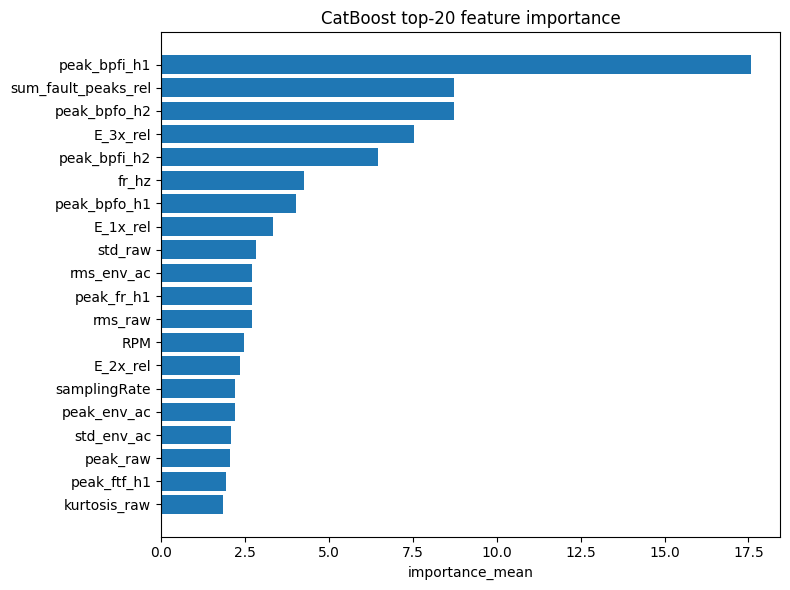

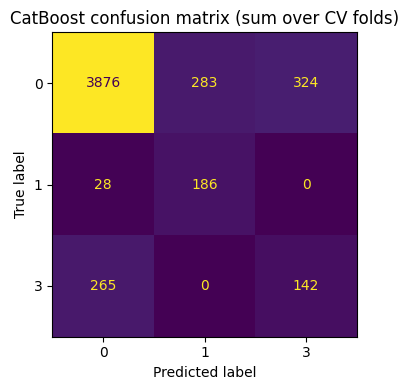

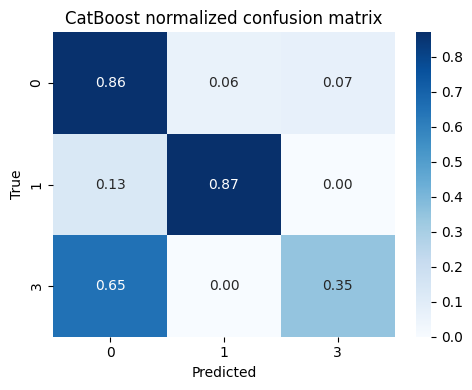

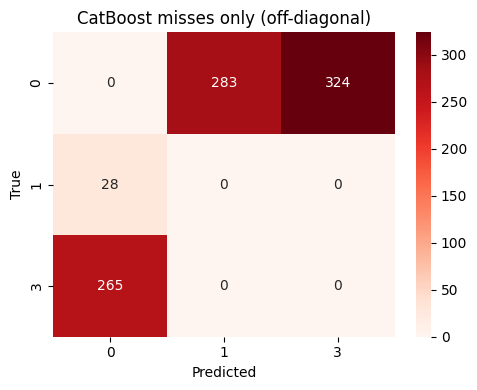

In [ ]:
# Диагностика CatBoost: важность признаков + матрица ошибок

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight

# --- Выбор сценария для диагностики ---
# "all_classes" -> [0,1,2,3] (сценарий group split по всем классам)
# "drop_class_2" -> [0,1,3] (сценарий без класса 2)
SCENARIO_DIAG = "drop_class_2"
TOP_N = 20

if SCENARIO_DIAG == "all_classes":
    X_diag = X_base.reset_index(drop=True).copy()
    y_diag = y_base.reset_index(drop=True).copy()
    groups_diag = groups_base.reset_index(drop=True).copy()
    labels_eval = [0, 1, 2, 3]
    scenario_name = "CatBoost diagnostics: all classes"
elif SCENARIO_DIAG == "drop_class_2":
    X_diag = X_3class.reset_index(drop=True).copy()
    y_diag = y_3class.reset_index(drop=True).copy()
    groups_diag = groups_3class.reset_index(drop=True).copy()
    labels_eval = [0, 1, 3]
    scenario_name = "CatBoost diagnostics: drop class 2"
else:
    raise ValueError("SCENARIO_DIAG должен быть 'all_classes' или 'drop_class_2'")

# Берем тот же CV-подход, что и в основном пайплайне
cv_name, n_splits, folds = pick_group_folds(
    X=X_diag,
    y=y_diag,
    groups=groups_diag,
    required_train_labels=[1, 3],
    random_state=RANDOM_STATE,
)

print(f"{scenario_name}")
print(f"CV: {cv_name}, n_splits={n_splits}")

# Фабрика CatBoost из вашего baseline-блока
cat_factory = build_model_factories(random_state=RANDOM_STATE)["CatBoost"]

cm_sum = np.zeros((len(labels_eval), len(labels_eval)), dtype=int)
importances = []

for fold, (tr_idx, te_idx) in enumerate(folds, 1):
    Xtr, Xte = X_diag.iloc[tr_idx].copy(), X_diag.iloc[te_idx].copy()
    ytr, yte = y_diag.iloc[tr_idx].copy(), y_diag.iloc[te_idx].copy()

    if UNDERSAMPLE_ZERO:
        Xtr, ytr = undersample_zero_train(
            Xtr, ytr, ratio=ZERO_TO_FAULT_RATIO, random_state=1000 + fold
        )

    # Кодирование классов внутри фолда (чтобы CatBoost работал устойчиво при неполном наборе классов)
    train_classes = np.sort(ytr.unique())
    enc = {int(c): i for i, c in enumerate(train_classes)}
    dec = {i: int(c) for i, c in enumerate(train_classes)}

    ytr_enc = ytr.map(enc).astype(int)
    sw = compute_sample_weight(class_weight="balanced", y=ytr_enc)

    model = cat_factory(len(train_classes))
    model.fit(Xtr, ytr_enc, sample_weight=sw)

    pred_enc = np.asarray(model.predict(Xte)).reshape(-1).astype(int)
    y_pred = np.array([dec.get(int(p), int(train_classes[0])) for p in pred_enc], dtype=int)
    y_true = yte.to_numpy().astype(int)

    # Матрица ошибок
    cm_fold = confusion_matrix(y_true, y_pred, labels=labels_eval)
    cm_sum += cm_fold

    # Важность признаков
    importances.append(model.get_feature_importance())

# ---------- Важность признаков ----------
imp_mean = np.mean(np.vstack(importances), axis=0)
imp_std = np.std(np.vstack(importances), axis=0)

imp_df = pd.DataFrame({
    "feature": X_diag.columns,
    "importance_mean": imp_mean,
    "importance_std": imp_std
}).sort_values("importance_mean", ascending=False)

print(f"\nTop-{TOP_N} признаков CatBoost:")
display(imp_df.head(TOP_N))

plt.figure(figsize=(8, 6))
plot_df = imp_df.head(TOP_N).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("importance_mean")
plt.title(f"CatBoost top-{TOP_N} feature importance")
plt.tight_layout()
plt.show()

# ---------- Матрица ошибок ----------
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_sum, display_labels=labels_eval).plot(
    ax=ax, values_format="d", colorbar=False
)
ax.set_title("CatBoost confusion matrix (sum over CV folds)")
plt.tight_layout()
plt.show()

# Нормированная матрица (по строкам) + отдельная карта промахов
cm_norm = cm_sum.astype(float) / np.clip(cm_sum.sum(axis=1, keepdims=True), 1, None)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_eval, yticklabels=labels_eval)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CatBoost normalized confusion matrix")
plt.tight_layout()
plt.show()

cm_miss = cm_sum.copy()
np.fill_diagonal(cm_miss, 0)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_miss, annot=True, fmt="d", cmap="Reds",
            xticklabels=labels_eval, yticklabels=labels_eval)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CatBoost misses only (off-diagonal)")
plt.tight_layout()
plt.show()


## Применимость в реальных условиях
Выбранный baseline-подход практичен для промышленной диагностики: модели интерпретируемы, быстро обучаются
и удобны для мониторинга через recall по классам. Group-валидация лучше приближает условия эксплуатации,
снижая оптимистичность оценки при попадании близких наблюдений одновременно в train и test. Однако обучение на найденных данных показало, что этих данных недостаточно для точного определния дефектов. Так же если обратиться к существующим исследованиям на тему диагностики дефектов для достижения качественного результата необходимо использовать другие модели (и возможно больше относительных признаков таких как отношение  суммарной энергии дефектов к СКЗ сигнала)


## Итоги
Ноутбук структурирован вокруг baseline-этапа: три последовательных сценария обучения и единые компактные
сводные таблицы для сравнения моделей. Это формирует устойчивую основу для следующих итераций по признакам. Работа требует дальнейшей проработки и исследования алтернативных путей решения задачи, но уже на текущем этапе видно, что задача реализуема.
